In [1]:
import os
import time
import numpy as np
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"] = "platform"
import jax
import jax.numpy as jnp
import optax
from jax.scipy.spatial.transform import Rotation
from orbax.checkpoint import PyTreeCheckpointer
from flax.training.train_state import TrainState
from matplotlib import pyplot as plt

from lotf import LOTF_PATH
from lotf.envs import HoveringStateEnv, rollout
from lotf.envs.wrappers import MinMaxObservationWrapper
from lotf.modules import (
    MLP,
    LatentConditionedResidualDynamics,
    RecurrentTrajectoryEncoder,
)
from lotf.objects import Quadrotor

%matplotlib inline

# Joint Training of the Trajectory Encoder and Residual Dynamics

## 1. Seed

In [2]:
seed = 0
master_key = jax.random.key(seed)

# Give every stochastic stage its own reproducible stream. Unlike repeatedly
# splitting one mutable notebook key, these keys do not depend on cell reruns.
def experiment_key(stream_id):
    return jax.random.fold_in(master_key, stream_id)

key = master_key  # Kept only for compatibility with exploratory cells.

## 2. Define Simulation Dynamics Config

In [3]:
# simulation dynamics config
sim_dyn_config = {
    "use_high_fidelity": False,           # stand-in for the disturbed/real system
    "use_forward_residual": False,       # whether to use residual dynamics in forward simulation
}

# No residual parameters are read when use_forward_residual=False. Passing an
# empty pytree avoids restoring the legacy CUDA-sharded dummy checkpoint.
dummy_residual_params = {}

## 3. Create Quadrotor Object and Data-Collection Environment

In [4]:
# simulation parameters
sim_dt = 0.02
max_sim_time = 5.0

# quadrotor object
quad_obj = Quadrotor.from_name("example_quad", sim_dyn_config)

eval_env = HoveringStateEnv(
    max_steps_in_episode=int(max_sim_time / sim_dt),
    dt=sim_dt,
    delay=0.04,
    quad_obj=quad_obj,
    margin=0.5,
    hover_target=[1.5, 0.0, 1.5],
    apply_hidden_acceleration=True,  # equation (2): v_dot += w
)
eval_env = MinMaxObservationWrapper(eval_env)

# get dims
action_dim = eval_env.action_space.shape[0]
obs_dim = eval_env.observation_space.shape[0]

print("====== eval_env info ======")
print(f"action_dim: {action_dim}")
print(f"obs_dim: {obs_dim}")

====== eval_env info ======
action_dim: 4
obs_dim: 27


## 4. Load the Trained Policy

In [5]:
policy_name = "state_hovering_params"

# create policy network
base_policy_net = MLP(
    [obs_dim, 512, 512, action_dim],
    action_bias=eval_env.hovering_action,
)

path = LOTF_PATH + "/../checkpoints/policy/" + policy_name
ckptr = PyTreeCheckpointer()
base_policy_params = ckptr.restore(path)
# define policy function
def policy_trained(obs, key):
    return base_policy_net.apply(base_policy_params, obs)

/home/dimitria/venvs/diff-sim-env/lib/python3.12/site-packages/orbax/checkpoint/type_handlers.py:1330: UserWarning: Couldn't find sharding info under RestoreArgs. Populating sharding info from sharding file. Please note restoration time will be slightly increased due to reading from file instead of directly from RestoreArgs. Note also that this option is unsafe when restoring on a different topology than the checkpoint was saved with.
  warnings.warn(


## 5. Collect Rollouts with Fixed Wind Acceleration

In [6]:
# HoveringStateEnv samples one row from wind_z_table.csv at reset. We retain
# the sampled wind acceleration for the whole rollout but ignore the paired
# CSV latent completely: the encoder must infer its own condition online.
num_rollouts = 12000
# Add small, independently sampled, bounded excitation only during training
# data collection. Validation and open-loop rollouts still use policy_trained.
collection_thrust_excitation_bound = (
    0.03 * eval_env.hovering_action[0]
)
collection_body_rate_excitation_bound = jnp.array(
    [0.12, 0.12, 0.12], dtype=eval_env.hovering_action.dtype
)
collection_action_excitation_bound = jnp.concatenate([
    collection_thrust_excitation_bound[None],
    collection_body_rate_excitation_bound,
])

def collection_policy_with_action_excitation(obs, key):
    key_policy, key_excitation = jax.random.split(key)
    nominal_action = policy_trained(obs, key_policy)
    excitation = jax.random.uniform(
        key_excitation,
        shape=nominal_action.shape,
        minval=-collection_action_excitation_bound,
        maxval=collection_action_excitation_bound,
    )
    return jnp.clip(
        nominal_action + excitation,
        eval_env.action_space.low,
        eval_env.action_space.high,
    )

key_rollouts = experiment_key(1)
rollout_keys = jax.random.split(key_rollouts, num_rollouts)
parallel_rollout = jax.vmap(rollout, in_axes=(None, 0, None, None))
trajectories = parallel_rollout(
    eval_env, rollout_keys, collection_policy_with_action_excitation,
    dummy_residual_params,
)

env_states = trajectories.state
quad_states = env_states.quadrotor_state

# Convert rotation matrices to the paper's state convention: (p, q, v).
def state_vectors(position, rotation_matrix, velocity):
    quaternion_xyzw = Rotation.from_matrix(rotation_matrix).as_quat()
    quaternion_wxyz = jnp.concatenate(
        [quaternion_xyzw[..., 3:], quaternion_xyzw[..., :3]], axis=-1
    )
    return jnp.concatenate([position, quaternion_wxyz, velocity], axis=-1)

states = state_vectors(
    quad_states.p[:, :-1], quad_states.R[:, :-1], quad_states.v[:, :-1]
)
# The action chosen from s_t is stored at the end of the successor state's
# action buffer, hence the 1: alignment below.
actions = env_states.last_actions[:, 1:, -1, :]
hidden_acceleration = env_states.hidden_acceleration[:, :-1, :]
state_actions = jnp.concatenate([states, actions], axis=-1)

# rollout(..., real_step=False) does not auto-reset. Keep the terminal
# transition itself, but discard any subsequent out-of-episode transitions.
done = jnp.logical_or(
    trajectories.terminated[:, 1:], trajectories.truncated[:, 1:]
)
valid_transition = (jnp.cumsum(done, axis=1) - done) == 0

assert states.shape[-1] == 10
assert actions.shape[-1] == 4
assert state_actions.shape[-1] == 14
assert jnp.all(hidden_acceleration == hidden_acceleration[:, :1, :])

_, rollouts_per_condition = jnp.unique(
    hidden_acceleration[:, 0, :], axis=0, return_counts=True
)
print(f"Collected {valid_transition.sum():,} valid transitions")
print(
    "Collection action-excitation bounds "
    f"[thrust, body rates]: {collection_action_excitation_bound}"
)
print(f"Conditions represented: {rollouts_per_condition.shape[0]}/17")
print(f"Rollouts per represented condition: {rollouts_per_condition}")

Collected 2,999,863 valid transitions
Collection action-excitation bounds [thrust, body rates]: [0.0565056 0.12      0.12      0.12     ]
Conditions represented: 17/17
Rollouts per represented condition: [699 708 688 759 742 689 674 701 676 719 696 689 711 691 694 755 709]


## 6. Build Non-Overlapping Latent Groups and Residual Targets

In [7]:
# Infer one latent from a 20-step context and share it across the following
# dynamics_horizon transitions. Advance each group by dynamics_horizon so a
# target transition is never assigned to multiple different latent codes.
context_length = 20
dynamics_horizon = 110
train_fraction = 0.9

num_transitions_per_rollout = state_actions.shape[1]
num_groups_per_rollout = (
    num_transitions_per_rollout - context_length
) // dynamics_horizon
assert num_groups_per_rollout > 0
group_start_indices = (
    jnp.arange(num_groups_per_rollout) * dynamics_horizon
)

# Split whole rollouts before normalization or grouping. Groups from a rollout
# can therefore never appear in both training and validation.
key_split = experiment_key(2)
rollout_permutation = jax.random.permutation(key_split, num_rollouts)
num_train_rollouts = int(train_fraction * num_rollouts)
train_rollout_indices = rollout_permutation[:num_train_rollouts]
train_rollout_mask = jnp.zeros(num_rollouts, dtype=bool)
train_rollout_mask = train_rollout_mask.at[train_rollout_indices].set(True)

normalization_mask = train_rollout_mask[:, None] & valid_transition
input_mean = state_actions[normalization_mask].mean(axis=0)
input_std = jnp.maximum(
    state_actions[normalization_mask].std(axis=0), 1e-6
)
normalized_state_actions = (state_actions - input_mean) / input_std

context_transition_indices = (
    group_start_indices[:, None]
    + jnp.arange(context_length)[None, :]
)
target_transition_indices = (
    group_start_indices[:, None]
    + context_length
    + jnp.arange(dynamics_horizon)[None, :]
)
assert jnp.unique(target_transition_indices).size == (
    num_groups_per_rollout * dynamics_horizon
)

grouped_contexts = normalized_state_actions[:, context_transition_indices]
grouped_dynamics_inputs = normalized_state_actions[:, target_transition_indices]
context_valid = valid_transition[:, context_transition_indices].all(axis=-1)
targets_valid = valid_transition[:, target_transition_indices].all(axis=-1)
valid_context = context_valid & targets_valid

contexts = grouped_contexts[valid_context]
dynamics_inputs = grouped_dynamics_inputs[valid_context]
context_rollout_grid = jnp.broadcast_to(
    jnp.arange(num_rollouts)[:, None], valid_context.shape
)
context_time_grid = jnp.broadcast_to(
    (group_start_indices + context_length)[None, :],
    valid_context.shape,
)
context_rollout_ids = context_rollout_grid[valid_context]
context_times = context_time_grid[valid_context]

# Evaluate the nominal rigid-body prior on every target transition. Its delay
# remains identical to the data-collection environment.
prior_dyn_config = {
    "use_high_fidelity": False,
    "use_forward_residual": False,
}
prior_env = HoveringStateEnv(
    max_steps_in_episode=int(max_sim_time / sim_dt),
    dt=sim_dt,
    delay=0.04,
    quad_obj=Quadrotor.from_name("example_quad", prior_dyn_config),
    apply_hidden_acceleration=False,
    margin=0.5,
    hover_target=[1.5, 0.0, 1.5],
)

transition_states = jax.tree.map(
    lambda leaf: leaf[:, :num_transitions_per_rollout].reshape(
        (-1,) + leaf.shape[2:]
    ),
    env_states,
)
observed_next_quad_states = jax.tree.map(
    lambda leaf: leaf[:, 1:num_transitions_per_rollout + 1].reshape(
        (-1,) + leaf.shape[2:]
    ),
    quad_states,
)
prior_actions = actions.reshape(-1, action_dim)
key_prior = experiment_key(3)
prior_keys = jax.random.split(key_prior, prior_actions.shape[0])

@jax.jit
def evaluate_prior(prior_states, prior_actions, prior_keys):
    def prior_step(state, action, step_key):
        transition = prior_env._step(state, action, {}, step_key)
        return transition.state.quadrotor_state

    return jax.vmap(prior_step)(prior_states, prior_actions, prior_keys)

# Evaluate each physical transition once in fixed-size batches to bound
# device memory during nominal-prior construction.
prior_batch_size = 2048
num_prior_transitions = prior_actions.shape[0]
num_padded_prior_transitions = (
    (num_prior_transitions + prior_batch_size - 1) // prior_batch_size
    * prior_batch_size
)
prior_padding_indices = jnp.minimum(
    jnp.arange(num_padded_prior_transitions),
    num_prior_transitions - 1,
)
padded_transition_states = jax.tree.map(
    lambda leaf: leaf[prior_padding_indices], transition_states
)
padded_prior_actions = prior_actions[prior_padding_indices]
padded_prior_keys = prior_keys[prior_padding_indices]
prior_output_chunks = []
for batch_start in range(0, num_padded_prior_transitions, prior_batch_size):
    batch_stop = batch_start + prior_batch_size
    prior_output_chunks.append(evaluate_prior(
        jax.tree.map(
            lambda leaf: leaf[batch_start:batch_stop],
            padded_transition_states,
        ),
        padded_prior_actions[batch_start:batch_stop],
        padded_prior_keys[batch_start:batch_stop],
    ))
prior_next_quad_states = jax.tree.map(
    lambda *chunks: jnp.concatenate(chunks, axis=0)[:num_prior_transitions],
    *prior_output_chunks,
)

def state_difference(observed, nominal):
    # Hovering predicts translational residuals only. Orientation is advanced
    # entirely by the analytical body-rate dynamics in the physics prior.
    return jnp.concatenate(
        [observed.p - nominal.p, observed.v - nominal.v], axis=-1
    )

transition_residual_targets = state_difference(
    observed_next_quad_states, prior_next_quad_states
).reshape(num_rollouts, num_transitions_per_rollout, -1)
residual_targets = (
    transition_residual_targets[:, target_transition_indices][valid_context]
)
assert residual_targets.shape[-1] == 6

training_context_mask = train_rollout_mask[context_rollout_ids]
train_contexts = contexts[training_context_mask]
train_dynamics_inputs = dynamics_inputs[training_context_mask]
train_targets = residual_targets[training_context_mask]
validation_contexts = contexts[~training_context_mask]
validation_dynamics_inputs = dynamics_inputs[~training_context_mask]
validation_targets = residual_targets[~training_context_mask]
validation_rollout_ids = context_rollout_ids[~training_context_mask]
validation_context_times = context_times[~training_context_mask]
train_targets.block_until_ready()
validation_targets.block_until_ready()
del grouped_contexts, grouped_dynamics_inputs, normalized_state_actions
del transition_states, observed_next_quad_states, prior_next_quad_states
del padded_transition_states, padded_prior_actions, padded_prior_keys
del prior_output_chunks, transition_residual_targets, prior_padding_indices
jax.clear_caches()
print(f"Training rollouts:   {num_train_rollouts}")
print(f"Validation rollouts: {num_rollouts - num_train_rollouts}")
print(f"Training contexts:   {train_contexts.shape[0]:,}")
print(f"Validation contexts: {validation_contexts.shape[0]:,}")
print(f"Complete latent groups per full rollout: {num_groups_per_rollout}")
print(f"Context shape:       {train_contexts.shape[1:]}")
print(f"Targets per latent:  {dynamics_horizon}")
print(
    "Incomplete tail transitions discarded per full rollout: "
    f"{(num_transitions_per_rollout - context_length) % dynamics_horizon}"
)


Training rollouts:   10800
Validation rollouts: 1200
Training contexts:   21,598
Validation contexts: 2,400
Complete latent groups per full rollout: 2
Context shape:       (20, 14)
Targets per latent:  110
Incomplete tail transitions discarded per full rollout: 10


## 7. Create the Encoder, Decoder, and FiLM Residual Dynamics

In [8]:
state_action_dim = state_actions.shape[-1]
latent_dim = 12

trajectory_encoder = RecurrentTrajectoryEncoder(
    state_action_dim=state_action_dim,
    context_length=context_length,
    latent_dim=latent_dim,
    projection_dim=128,
    hidden_dim=128,
)
residual_model = LatentConditionedResidualDynamics(
    state_action_dim=state_action_dim,
    latent_dim=latent_dim,
    hidden_dim=256,
    num_blocks=2,
    predict_orientation=False,
)
# G_eta is auxiliary: it reconstructs the complete normalized context from z.
context_decoder = MLP(
    [latent_dim, 256, 256, context_length * state_action_dim],
    nonlinearity=jax.nn.gelu,
)

key_encoder, key_residual, key_decoder = jax.random.split(
    experiment_key(4), 3
)
initial_joint_params = {
    "encoder": trajectory_encoder.initialize(key_encoder),
    "residual": residual_model.initialize(key_residual),
    "decoder": context_decoder.initialize(key_decoder),
}

def joint_forward(params, contexts, normalized_dynamics_inputs):
    latents = trajectory_encoder.apply(params["encoder"], contexts)
    expanded_latents = jnp.broadcast_to(
        latents[..., None, :],
        normalized_dynamics_inputs.shape[:-1] + (latent_dim,),
    )
    predicted_residuals = residual_model.apply(
        params["residual"], normalized_dynamics_inputs, expanded_latents
    )
    reconstructed_contexts = context_decoder.apply(
        params["decoder"], latents
    ).reshape(contexts.shape)
    return latents, predicted_residuals, reconstructed_contexts

dummy_latent, dummy_residuals, dummy_reconstruction = joint_forward(
    initial_joint_params, train_contexts[0], train_dynamics_inputs[0]
)
assert dummy_latent.shape == (latent_dim,)
assert dummy_residuals.shape == (dynamics_horizon, 6)
assert dummy_reconstruction.shape == (context_length, state_action_dim)
print(f"Encoder output:        {dummy_latent.shape}")
print(f"Residual-head output: {dummy_residuals.shape}")
print(f"Decoder output:        {dummy_reconstruction.shape}")


Encoder output:        (12,)
Residual-head output: (110, 6)
Decoder output:        (20, 14)


## 8. Joint Training with Normalized Residual Targets

In [29]:
# Compute target statistics from training rollouts only. Each of the six output
# coordinates is standardized independently; validation data never contributes.
# lambda_rec is exposed explicitly because the paper does not prescribe one
# universal task-independent value. L_rec acts on normalized context channels.
lambda_rec = 1e-7
lambda_mmd_max = 1e-4
mmd_kernel_sigma = 2.0
mmd_warmup_steps = 2000
mmd_ramp_steps = 4000
mmd_prior_resample_period = 100
huber_delta = 1
batch_size = min(128, train_contexts.shape[0])
num_training_steps = 20000
steps_per_training_chunk = 100
print_every = 100  # Set to 1 to print every optimizer update.
assert num_training_steps % steps_per_training_chunk == 0
assert mmd_kernel_sigma > 0.0
assert mmd_warmup_steps >= 0
assert mmd_ramp_steps > 0
assert mmd_prior_resample_period > 0

residual_target_mean = train_targets.mean(axis=(0, 1))
residual_target_std = jnp.maximum(
    train_targets.std(axis=(0, 1)), 1e-8
)
normalized_train_targets = (
    train_targets - residual_target_mean
) / residual_target_std
normalized_validation_targets = (
    validation_targets - residual_target_mean
) / residual_target_std

component_names = [
    "delta_p_x", "delta_p_y", "delta_p_z",
    "delta_v_x", "delta_v_y", "delta_v_z",
]

print("Training residual-target statistics:")
for name, mean, std in zip(
    component_names, residual_target_mean, residual_target_std
):
    print(f"  {name:>10s}: mean={mean:.6e}, std={std:.6e}")

# Initialize the target-normalized encoder, residual dynamics, and decoder.
target_normalized_train_state = TrainState.create(
    apply_fn=joint_forward,
    params=initial_joint_params,
    tx=optax.adam(learning_rate=3e-4),
)

def biased_rbf_mmd(encoded_latents, prior_latents):
    def rbf_kernel(left, right):
        # Compute pairwise squared distances without materializing an
        # (N, N, latent_dim) broadcasted difference tensor.
        left_squared_norm = jnp.sum(jnp.square(left), axis=-1)[:, None]
        right_squared_norm = jnp.sum(jnp.square(right), axis=-1)[None, :]
        squared_distance = jnp.maximum(
            left_squared_norm
            + right_squared_norm
            - 2.0 * (left @ right.T),
            0.0,
        )
        return jnp.exp(
            -squared_distance / (2.0 * mmd_kernel_sigma**2)
        )

    # Equation (17): biased finite-sample estimator, including diagonal
    # kernel terms in both within-distribution sums.
    return (
        rbf_kernel(encoded_latents, encoded_latents).mean()
        + rbf_kernel(prior_latents, prior_latents).mean()
        - 2.0 * rbf_kernel(encoded_latents, prior_latents).mean()
    )

def mmd_weight_at_step(step):
    ramp_fraction = jnp.clip(
        (step - mmd_warmup_steps) / mmd_ramp_steps, 0.0, 1.0
    )
    return lambda_mmd_max * ramp_fraction

def target_normalized_joint_loss(
    params, contexts, dynamics_inputs, normalized_targets,
    prior_latents, mmd_weight,
):
    encoded_latents, normalized_predictions, reconstructions = joint_forward(
        params, contexts, dynamics_inputs
    )
    dynamics_loss = optax.huber_loss(
        normalized_predictions, normalized_targets, delta=huber_delta
    ).mean()
    # Equation (16): average the per-context squared L2 norm. Sum over
    # context time and feature dimensions, then average over the batch.
    reconstruction_loss = jnp.sum(
        jnp.square(reconstructions - contexts), axis=(-2, -1)
    ).mean()
    mmd_loss = biased_rbf_mmd(encoded_latents, prior_latents)
    total_loss = (
        dynamics_loss
        + lambda_rec * reconstruction_loss
        + mmd_weight * mmd_loss
    )
    return total_loss, (dynamics_loss, reconstruction_loss, mmd_loss)

@jax.jit
def train_target_normalized_chunk(
    train_state, rng_key, prior_latents, first_step
):
    def training_step(carry, step):
        state, step_key, cached_prior_latents = carry
        step_key, sample_key = jax.random.split(step_key)
        batch_indices = jax.random.randint(
            sample_key, (batch_size,), 0, train_contexts.shape[0]
        )
        should_resample_prior = (
            step % mmd_prior_resample_period == 0
        )
        prior_sample_key = jax.random.fold_in(
            mmd_prior_base_key, step // mmd_prior_resample_period
        )
        cached_prior_latents = jax.lax.cond(
            should_resample_prior,
            lambda key: jax.random.normal(
                key, (batch_size, latent_dim)
            ),
            lambda _: cached_prior_latents,
            prior_sample_key,
        )
        mmd_weight = mmd_weight_at_step(step)
        (loss, (dyn_loss, rec_loss, mmd_loss)), gradients = jax.value_and_grad(
            target_normalized_joint_loss, has_aux=True
        )(
            state.params,
            train_contexts[batch_indices],
            train_dynamics_inputs[batch_indices],
            normalized_train_targets[batch_indices],
            cached_prior_latents,
            mmd_weight,
        )
        state = state.apply_gradients(grads=gradients)

        def print_current_losses(_):
            jax.debug.print(
                "Target-normalized training step {}", step, ordered=True
            )
            jax.debug.print("L_dyn: {}", dyn_loss, ordered=True)
            jax.debug.print("L_rec: {}", rec_loss, ordered=True)
            jax.debug.print(
                "weighted L_rec: {}",
                lambda_rec * rec_loss,
                ordered=True,
            )
            jax.debug.print("L_mmd: {}", mmd_loss, ordered=True)
            jax.debug.print(
                "lambda_mmd: {}", mmd_weight, ordered=True
            )
            jax.debug.print(
                "weighted L_mmd: {}",
                mmd_weight * mmd_loss,
                ordered=True,
            )
            return jnp.int32(0)

        should_print = (step % print_every == 0) | (
            step == num_training_steps - 1
        )
        jax.lax.cond(
            should_print,
            print_current_losses,
            lambda _: jnp.int32(0),
            operand=None,
        )
        loss_components = jnp.stack([
            loss, dyn_loss, rec_loss, mmd_loss, mmd_weight * mmd_loss
        ])
        return (state, step_key, cached_prior_latents), loss_components

    (train_state, rng_key, prior_latents), losses = jax.lax.scan(
        training_step,
        (train_state, rng_key, prior_latents),
        first_step + jnp.arange(steps_per_training_chunk),
    )
    return train_state, rng_key, prior_latents, losses

# Prior samples use a separate deterministic stream, so adding MMD does not
# alter the existing minibatch-index sequence. One N(0, I) batch is cached
# and refreshed according to mmd_prior_resample_period.
mmd_prior_base_key = experiment_key(50)
target_normalized_prior_latents = jax.random.normal(
    jax.random.fold_in(mmd_prior_base_key, 0),
    (batch_size, latent_dim),
)
target_normalized_initial_total, (
    target_normalized_initial_dyn,
    target_normalized_initial_rec,
    target_normalized_initial_mmd,
) = target_normalized_joint_loss(
    target_normalized_train_state.params,
    train_contexts[:batch_size],
    train_dynamics_inputs[:batch_size],
    normalized_train_targets[:batch_size],
    target_normalized_prior_latents,
    mmd_weight_at_step(jnp.asarray(0)),
)
# Use the same fixed minibatch-index stream on every execution of this cell.
key_target_normalized_train = experiment_key(5)
compiled_train_target_normalized_chunk = train_target_normalized_chunk.lower(
    target_normalized_train_state,
    key_target_normalized_train,
    target_normalized_prior_latents,
    jnp.asarray(0),
).compile()
target_normalized_training_start = time.perf_counter()
target_normalized_loss_chunks = []
num_training_chunks = num_training_steps // steps_per_training_chunk
for training_chunk in range(num_training_chunks):
    first_step = jnp.asarray(training_chunk * steps_per_training_chunk)
    (
        target_normalized_train_state,
        key_target_normalized_train,
        target_normalized_prior_latents,
        chunk_losses,
    ) = compiled_train_target_normalized_chunk(
        target_normalized_train_state,
        key_target_normalized_train,
        target_normalized_prior_latents,
        first_step,
    )
    chunk_losses.block_until_ready()
    target_normalized_loss_chunks.append(chunk_losses)
target_normalized_training_losses = jnp.concatenate(
    target_normalized_loss_chunks, axis=0
)
target_normalized_training_duration = (
    time.perf_counter() - target_normalized_training_start
)
target_normalized_final_mmd_weight = mmd_weight_at_step(
    jnp.asarray(num_training_steps - 1)
)

# Bound post-training validation memory. This computes the same L_dyn and
# L_rec reductions as a single full validation call, but never sends all
# contexts and dynamics transitions through the networks simultaneously.
validation_batch_size = min(128, validation_contexts.shape[0])

@jax.jit
def target_normalized_validation_sums(
    params, contexts, dynamics_inputs, normalized_targets
):
    _, normalized_predictions, reconstructions = joint_forward(
        params, contexts, dynamics_inputs
    )
    dynamics_loss_sum = optax.huber_loss(
        normalized_predictions, normalized_targets, delta=huber_delta
    ).sum()
    reconstruction_loss_sum = jnp.sum(
        jnp.square(reconstructions - contexts)
    )
    return dynamics_loss_sum, reconstruction_loss_sum

validation_dyn_sum = jnp.asarray(0.0)
validation_rec_sum = jnp.asarray(0.0)
for validation_start in range(
    0, validation_contexts.shape[0], validation_batch_size
):
    validation_stop = min(
        validation_start + validation_batch_size,
        validation_contexts.shape[0],
    )
    batch_dyn_sum, batch_rec_sum = target_normalized_validation_sums(
        target_normalized_train_state.params,
        validation_contexts[validation_start:validation_stop],
        validation_dynamics_inputs[validation_start:validation_stop],
        normalized_validation_targets[validation_start:validation_stop],
    )
    validation_dyn_sum = validation_dyn_sum + batch_dyn_sum
    validation_rec_sum = validation_rec_sum + batch_rec_sum
target_normalized_validation_dyn = validation_dyn_sum / (
    normalized_validation_targets.size
)
target_normalized_validation_rec = validation_rec_sum / (
    validation_contexts.shape[0]
)

# Validation MMD is evaluation-only and uses a bounded subset to avoid an
# unnecessarily large quadratic kernel matrix. Training MMD remains exactly
# the batch-size estimator used in every optimizer update.
mmd_validation_sample_size = min(1024, validation_contexts.shape[0])
mmd_validation_indices = jax.random.choice(
    experiment_key(51),
    validation_contexts.shape[0],
    shape=(mmd_validation_sample_size,),
    replace=False,
)
target_normalized_validation_latents_for_mmd = trajectory_encoder.apply(
    target_normalized_train_state.params["encoder"],
    validation_contexts[mmd_validation_indices],
)
target_normalized_validation_prior_latents = jax.random.normal(
    experiment_key(52),
    (mmd_validation_sample_size, latent_dim),
)
target_normalized_validation_mmd = biased_rbf_mmd(
    target_normalized_validation_latents_for_mmd,
    target_normalized_validation_prior_latents,
)
target_normalized_validation_total = (
    target_normalized_validation_dyn
    + lambda_rec * target_normalized_validation_rec
    + target_normalized_final_mmd_weight
    * target_normalized_validation_mmd
)

print(f"Initial normalized-target total: {target_normalized_initial_total:.6e}")
print(f"Initial normalized L_dyn:        {target_normalized_initial_dyn:.6e}")
print(f"Initial L_rec:                   {target_normalized_initial_rec:.6e}")
print(f"Initial L_mmd:                   {target_normalized_initial_mmd:.6e}")
print(
    f"Final normalized-target total:   "
    f"{target_normalized_training_losses[-1, 0]:.6e}"
)
print(
    f"Final normalized L_dyn:          "
    f"{target_normalized_training_losses[-1, 1]:.6e}"
)
print(
    f"Final L_rec:                     "
    f"{target_normalized_training_losses[-1, 2]:.6e}"
)
print(
    f"Final L_mmd:                     "
    f"{target_normalized_training_losses[-1, 3]:.6e}"
)
print(
    f"Final weighted L_mmd:            "
    f"{target_normalized_training_losses[-1, 4]:.6e}"
)
print(f"Validation normalized L_dyn:     {target_normalized_validation_dyn:.6e}")
print(f"Validation L_rec:                {target_normalized_validation_rec:.6e}")
print(f"Validation L_mmd:                {target_normalized_validation_mmd:.6e}")
print(
    f"Validation weighted L_mmd:       "
    f"{target_normalized_final_mmd_weight * target_normalized_validation_mmd:.6e}"
)
print(f"Training time:                   {target_normalized_training_duration:.2f} s")


Training residual-target statistics:
   delta_p_x: mean=5.705926e-07, std=2.178504e-04
   delta_p_y: mean=-1.306830e-06, std=2.159263e-04
   delta_p_z: mean=0.000000e+00, std=1.000000e-08
   delta_v_x: mean=5.683987e-05, std=2.178396e-02
   delta_v_y: mean=-1.306556e-04, std=2.159235e-02
   delta_v_z: mean=0.000000e+00, std=1.000000e-08
Target-normalized training step 0
L_dyn: 0.2815614342689514
L_rec: 620.6424560546875
weighted L_rec: 6.206424586707726e-05
L_mmd: 0.309735506772995
lambda_mmd: 0.0
weighted L_mmd: 0.0
Target-normalized training step 100
L_dyn: 0.013068626634776592
L_rec: 532.61572265625
weighted L_rec: 5.326157406670973e-05
L_mmd: 0.13660281896591187
lambda_mmd: 0.0
weighted L_mmd: 0.0
Target-normalized training step 200
L_dyn: 0.007838230580091476
L_rec: 382.16058349609375
weighted L_rec: 3.821605787379667e-05
L_mmd: 0.13859876990318298
lambda_mmd: 0.0
weighted L_mmd: 0.0
Target-normalized training step 300
L_dyn: 0.0051235235296189785
L_rec: 354.4043884277344
weighted

## 9. Plot Target-Normalized Training Losses

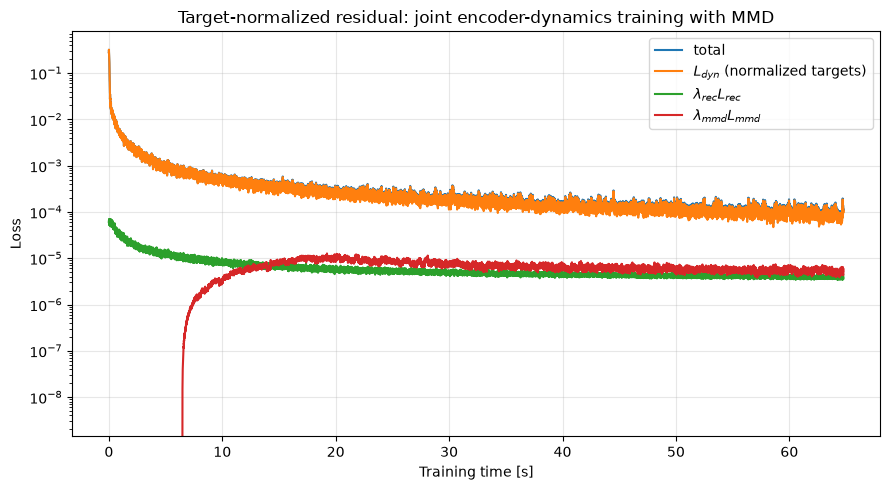

In [30]:
target_normalized_training_time_axis = jnp.linspace(
    0.0, target_normalized_training_duration, num_training_steps
)
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(
    target_normalized_training_time_axis,
    target_normalized_training_losses[:, 0],
    label="total",
)
ax.plot(
    target_normalized_training_time_axis,
    target_normalized_training_losses[:, 1],
    label=r"$L_{dyn}$ (normalized targets)",
)
ax.plot(
    target_normalized_training_time_axis,
    lambda_rec * target_normalized_training_losses[:, 2],
    label=r"$\lambda_{rec} L_{rec}$",
)
ax.plot(
    target_normalized_training_time_axis,
    target_normalized_training_losses[:, 4],
    label=r"$\lambda_{mmd} L_{mmd}$",
)
ax.set_yscale("log")
ax.set_xlabel("Training time [s]")
ax.set_ylabel("Loss")
ax.set_title(
    "Target-normalized residual: joint encoder-dynamics training with MMD"
)
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()



## 9.1 Save the Trained Encoder and Residual-Dynamics Model

In [31]:
# Save before running the memory-intensive validation sections. The params
# pytree contains the encoder, residual dynamics, and context decoder.
joint_model_checkpoint_name = "state_hovering_complete_mmd"
joint_model_checkpoint_directory = os.path.abspath(os.path.join(
    LOTF_PATH,
    "..",
    "checkpoints",
    "residual_dynamics",
    joint_model_checkpoint_name,
))
os.makedirs(
    os.path.dirname(joint_model_checkpoint_directory), exist_ok=True
)
joint_model_checkpoint = {
    "params": target_normalized_train_state.params,
    "input_mean": input_mean,
    "input_std": input_std,
    "residual_target_mean": residual_target_mean,
    "residual_target_std": residual_target_std,
    "configuration": {
        "context_length": jnp.asarray(context_length),
        "dynamics_horizon": jnp.asarray(dynamics_horizon),
        "state_action_dim": jnp.asarray(state_action_dim),
        "latent_dim": jnp.asarray(latent_dim),
        "lambda_rec": jnp.asarray(lambda_rec),
        "lambda_mmd_max": jnp.asarray(lambda_mmd_max),
        "mmd_kernel_sigma": jnp.asarray(mmd_kernel_sigma),
        "mmd_warmup_steps": jnp.asarray(mmd_warmup_steps),
        "mmd_ramp_steps": jnp.asarray(mmd_ramp_steps),
        "mmd_prior_resample_period": jnp.asarray(
            mmd_prior_resample_period
        ),
        "huber_delta": jnp.asarray(huber_delta),
        "num_training_steps": jnp.asarray(num_training_steps),
    },
}
joint_model_checkpointer = PyTreeCheckpointer()
joint_model_checkpointer.save(
    joint_model_checkpoint_directory,
    joint_model_checkpoint,
    force=True,
)
print("Saved trained joint model and normalization statistics to:")
print(f"  {joint_model_checkpoint_directory}")
print("Saved parameter groups:")
print(f"  {tuple(target_normalized_train_state.params.keys())}")


Saved trained joint model and normalization statistics to:
  /home/dimitria/PhD_codes/learning_on_the_fly/checkpoints/residual_dynamics/state_hovering_complete_mmd
Saved parameter groups:
  ('decoder', 'encoder', 'residual')


## 10. Collect Fresh Validation Rollouts

In [32]:
# This is a genuinely fresh evaluation dataset. Nothing in this cell updates
# the policy, encoder, decoder, or residual-dynamics parameters.
num_one_step_rollouts = 32
open_loop_validation_time = 5.0
one_step_num_steps = context_length + int(round(
    open_loop_validation_time / sim_dt
))
one_step_eval_env = HoveringStateEnv(
    max_steps_in_episode=one_step_num_steps,
    dt=sim_dt,
    delay=0.04,
    quad_obj=quad_obj,
    margin=0.5,
    hover_target=[1.5, 0.0, 1.5],
    apply_hidden_acceleration=True,
)
one_step_eval_env = MinMaxObservationWrapper(one_step_eval_env)
key_one_step_rollouts = experiment_key(6)
one_step_rollout_keys = jax.random.split(
    key_one_step_rollouts, num_one_step_rollouts
)
one_step_trajectories = parallel_rollout(
    one_step_eval_env,
    one_step_rollout_keys,
    policy_trained,
    dummy_residual_params,
)

one_step_env_states = one_step_trajectories.state
one_step_quad_states = one_step_env_states.quadrotor_state
one_step_states = state_vectors(
    one_step_quad_states.p[:, :-1],
    one_step_quad_states.R[:, :-1],
    one_step_quad_states.v[:, :-1],
)
one_step_actions = one_step_env_states.last_actions[:, 1:, -1, :]
one_step_state_actions = jnp.concatenate(
    [one_step_states, one_step_actions], axis=-1
)
one_step_normalized_state_actions = (
    one_step_state_actions - input_mean
) / input_std

one_step_done = jnp.logical_or(
    one_step_trajectories.terminated[:, 1:],
    one_step_trajectories.truncated[:, 1:],
)
one_step_valid_transition = (
    jnp.cumsum(one_step_done, axis=1) - one_step_done
) == 0
num_one_step_contexts = (
    one_step_state_actions.shape[1] - context_length
)
one_step_context_indices = (
    jnp.arange(num_one_step_contexts)[:, None]
    + jnp.arange(context_length)[None, :]
)
one_step_target_indices = (
    jnp.arange(num_one_step_contexts) + context_length
)
one_step_valid_context = (
    one_step_valid_transition[:, one_step_context_indices].all(axis=-1)
    & one_step_valid_transition[:, one_step_target_indices]
)

one_step_contexts = one_step_normalized_state_actions[
    :, one_step_context_indices
][one_step_valid_context]
one_step_inputs = one_step_normalized_state_actions[
    :, one_step_target_indices
][one_step_valid_context]
one_step_current_states = one_step_states[
    :, one_step_target_indices
][one_step_valid_context]
one_step_target_actions = one_step_actions[
    :, one_step_target_indices
][one_step_valid_context]
one_step_hidden_accelerations = one_step_env_states.hidden_acceleration[
    :, one_step_target_indices
][one_step_valid_context]
assert jnp.all(
    one_step_env_states.hidden_acceleration
    == one_step_env_states.hidden_acceleration[:, :1, :]
)

# Run the analytical prior once from each measured pre-transition state.
one_step_prior_states = jax.tree.map(
    lambda leaf: leaf[:, one_step_target_indices][one_step_valid_context],
    one_step_env_states,
)
one_step_observed_next_states = jax.tree.map(
    lambda leaf: leaf[:, one_step_target_indices + 1][one_step_valid_context],
    one_step_quad_states,
)
key_one_step_prior = experiment_key(7)
one_step_prior_keys = jax.random.split(
    key_one_step_prior, one_step_inputs.shape[0]
)
one_step_prior_next_states = evaluate_prior(
    one_step_prior_states,
    one_step_target_actions,
    one_step_prior_keys,
)
one_step_targets = state_difference(
    one_step_observed_next_states, one_step_prior_next_states
)
one_step_next_states = state_vectors(
    one_step_observed_next_states.p,
    one_step_observed_next_states.R,
    one_step_observed_next_states.v,
)

# Labels shared by one-step and open-loop validation.
head_slices = [slice(0, 3), slice(3, 6)]
head_labels = ["position", "velocity"]
head_units = ["m", "m/s"]
held_out_rollouts_to_plot = jnp.unique(validation_rollout_ids)[:4]

# Nominal errors are the baseline for the normalized model's learned correction.
nominal_position_rmse = jnp.sqrt(jnp.mean(jnp.square(
    one_step_prior_next_states.p - one_step_observed_next_states.p
)))
nominal_velocity_rmse = jnp.sqrt(jnp.mean(jnp.square(
    one_step_prior_next_states.v - one_step_observed_next_states.v
)))
print(f"Fresh one-step samples: {one_step_inputs.shape[0]:,}")


Fresh one-step samples: 8,000


## 11. Evaluate Target-Normalized One-Step Predictions

Held-out physical residual errors (target-normalized training):
   delta_p_x: MAE=3.101183e-06, RMSE=4.681021e-06
   delta_p_y: MAE=3.455250e-06, RMSE=5.168739e-06
   delta_p_z: MAE=1.293162e-11, RMSE=1.773734e-11
   delta_v_x: MAE=3.198738e-04, RMSE=4.737600e-04
   delta_v_y: MAE=3.524432e-04, RMSE=5.264346e-04
   delta_v_z: MAE=6.525594e-12, RMSE=1.022985e-11

Fresh one-step errors (target-normalized training):
Normalized-target L_dyn: 1.188185e-02
   delta_p_x: MAE=1.603461e-05, RMSE=4.120309e-05
   delta_p_y: MAE=1.637160e-05, RMSE=4.118595e-05
   delta_p_z: MAE=1.269680e-11, RMSE=1.752789e-11
   delta_v_x: MAE=1.611852e-03, RMSE=4.094293e-03
   delta_v_y: MAE=1.634610e-03, RMSE=4.088569e-03
   delta_v_z: MAE=5.443054e-12, RMSE=9.511100e-12
Physical one-step RMSE before -> after target-normalized correction:
  position: 1.744063e-04 -> 3.363483e-05 m
  velocity: 1.744037e-02 -> 3.340640e-03 m/s


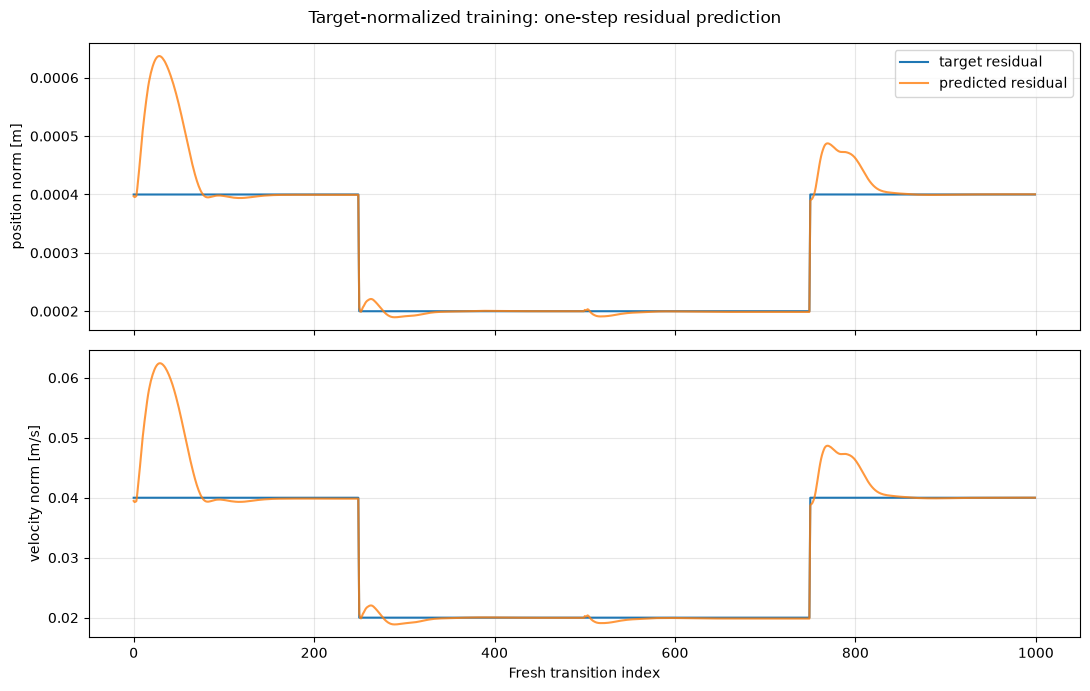

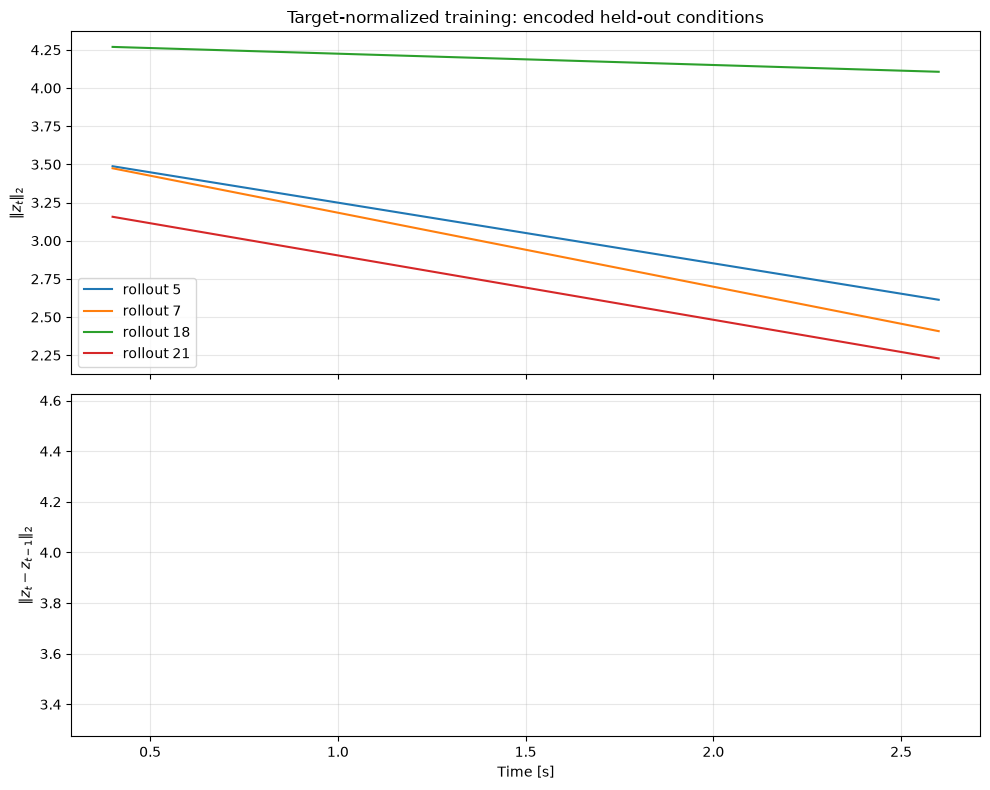

In [33]:
# Held-out contexts from the original rollout-wise split. Convert model outputs
# back to physical residual units before reporting errors.
(
    target_normalized_validation_latents,
    target_normalized_validation_predictions_norm,
    _,
) = joint_forward(
    target_normalized_train_state.params,
    validation_contexts,
    validation_dynamics_inputs,
)
target_normalized_validation_predictions = (
    target_normalized_validation_predictions_norm * residual_target_std
    + residual_target_mean
)
target_normalized_validation_predictions.block_until_ready()
target_normalized_validation_errors = (
    target_normalized_validation_predictions - validation_targets
)
target_normalized_component_mae = jnp.abs(
    target_normalized_validation_errors
).mean(axis=(0, 1))
target_normalized_component_rmse = jnp.sqrt(jnp.square(
    target_normalized_validation_errors
).mean(axis=(0, 1)))

print("Held-out physical residual errors (target-normalized training):")
for name, mae, rmse in zip(
    component_names,
    target_normalized_component_mae,
    target_normalized_component_rmse,
):
    print(f"  {name:>10s}: MAE={mae:.6e}, RMSE={rmse:.6e}")

# Evaluate the fresh one-step dataset collected in the preceding section.
target_normalized_one_step_latents = trajectory_encoder.apply(
    target_normalized_train_state.params["encoder"], one_step_contexts
)
target_normalized_one_step_predictions_norm = residual_model.apply(
    target_normalized_train_state.params["residual"],
    one_step_inputs,
    target_normalized_one_step_latents,
)
target_normalized_one_step_predictions = (
    target_normalized_one_step_predictions_norm * residual_target_std
    + residual_target_mean
)
one_step_dataset = {
    "context": one_step_contexts,
    "state": one_step_current_states,
    "action": one_step_target_actions,
    "next_state": one_step_next_states,
    "normalized_state_action": one_step_inputs,
    "target_residual": one_step_targets,
    "predicted_residual": target_normalized_one_step_predictions,
    "encoded_latent": target_normalized_one_step_latents,
    "hidden_acceleration_diagnostic": one_step_hidden_accelerations,
}
target_normalized_one_step_errors = (
    target_normalized_one_step_predictions - one_step_targets
)
target_normalized_one_step_mae = jnp.abs(
    target_normalized_one_step_errors
).mean(axis=0)
target_normalized_one_step_rmse = jnp.sqrt(jnp.square(
    target_normalized_one_step_errors
).mean(axis=0))
target_normalized_one_step_huber = optax.huber_loss(
    target_normalized_one_step_predictions_norm,
    (one_step_targets - residual_target_mean) / residual_target_std,
    delta=huber_delta,
).mean()

target_normalized_corrected_positions = (
    one_step_prior_next_states.p
    + target_normalized_one_step_predictions[:, :3]
)
target_normalized_corrected_velocities = (
    one_step_prior_next_states.v
    + target_normalized_one_step_predictions[:, 3:6]
)
target_normalized_corrected_position_rmse = jnp.sqrt(jnp.mean(jnp.square(
    target_normalized_corrected_positions - one_step_observed_next_states.p
)))
target_normalized_corrected_velocity_rmse = jnp.sqrt(jnp.mean(jnp.square(
    target_normalized_corrected_velocities - one_step_observed_next_states.v
)))

print("\nFresh one-step errors (target-normalized training):")
print(f"Normalized-target L_dyn: {target_normalized_one_step_huber:.6e}")
for name, mae, rmse in zip(
    component_names,
    target_normalized_one_step_mae,
    target_normalized_one_step_rmse,
):
    print(f"  {name:>10s}: MAE={mae:.6e}, RMSE={rmse:.6e}")
print("Physical one-step RMSE before -> after target-normalized correction:")
print(
    f"  position: {nominal_position_rmse:.6e} -> "
    f"{target_normalized_corrected_position_rmse:.6e} m"
)
print(
    f"  velocity: {nominal_velocity_rmse:.6e} -> "
    f"{target_normalized_corrected_velocity_rmse:.6e} m/s"
)

num_target_normalized_plot_samples = min(
    1000, one_step_inputs.shape[0]
)
target_normalized_plot_indices = jnp.arange(
    num_target_normalized_plot_samples
)
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
for ax, head_slice, head_label, head_unit in zip(
    axes, head_slices, head_labels, head_units
):
    ax.plot(
        target_normalized_plot_indices,
        jnp.linalg.norm(
            one_step_targets[
                :num_target_normalized_plot_samples, head_slice
            ],
            axis=-1,
        ),
        label="target residual",
    )
    ax.plot(
        target_normalized_plot_indices,
        jnp.linalg.norm(
            target_normalized_one_step_predictions[
                :num_target_normalized_plot_samples, head_slice
            ],
            axis=-1,
        ),
        label="predicted residual",
        alpha=0.8,
    )
    ax.set_ylabel(f"{head_label} norm [{head_unit}]")
    ax.grid(True, alpha=0.3)
axes[0].legend()
axes[-1].set_xlabel("Fresh transition index")
fig.suptitle(
    "Target-normalized training: one-step residual prediction"
)
fig.tight_layout()
plt.show()

# Show how the newly trained encoder varies across held-out real contexts.
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
for rollout_id in held_out_rollouts_to_plot:
    rollout_mask = validation_rollout_ids == rollout_id
    rollout_time = validation_context_times[rollout_mask] * sim_dt
    rollout_latents = target_normalized_validation_latents[rollout_mask]
    axes[0].plot(
        rollout_time,
        jnp.linalg.norm(rollout_latents, axis=-1),
        label=f"rollout {int(rollout_id)}",
    )
    axes[1].plot(
        rollout_time[1:],
        jnp.linalg.norm(
            rollout_latents[1:] - rollout_latents[:-1], axis=-1
        ),
    )
axes[0].set_ylabel(r"$\|z_t\|_2$")
axes[0].set_title(
    "Target-normalized training: encoded held-out conditions"
)
axes[0].legend()
axes[1].set_xlabel("Time [s]")
axes[1].set_ylabel(r"$\|z_t-z_{t-1}\|_2$")
for ax in axes:
    ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()


## 12. Prepare the Five-Second Open-Loop Evaluation

In [34]:
# Match the paper's dynamics evaluation: infer one latent from the measured
# context, then hold it fixed while recursively replaying the same recorded
# action sequence from the same measured initial state.
open_loop_horizon = int(round(open_loop_validation_time / sim_dt))
assert context_length + open_loop_horizon <= one_step_state_actions.shape[1]

# Include every rollout with a valid encoder context and at least one valid
# post-context transition. Targets after termination remain masked.
open_loop_context_valid = one_step_valid_transition[
    :, :context_length
].all(axis=1)
open_loop_available_steps = one_step_valid_transition[
    :, context_length:context_length + open_loop_horizon
].sum(axis=1)
open_loop_eligible = (
    open_loop_context_valid & (open_loop_available_steps > 0)
)
assert bool(jnp.any(open_loop_eligible)), (
    "No fresh rollout is valid beyond the initial encoder context"
)
open_loop_rollout_indices = jnp.flatnonzero(open_loop_eligible)
open_loop_valid_mask = one_step_valid_transition[
    open_loop_rollout_indices,
    context_length:context_length + open_loop_horizon,
]

open_loop_initial_states = jax.tree.map(
    lambda leaf: leaf[open_loop_rollout_indices, context_length],
    one_step_env_states,
)
open_loop_initial_contexts = one_step_normalized_state_actions[
    open_loop_rollout_indices, :context_length
]
open_loop_actions = one_step_actions[
    open_loop_rollout_indices,
    context_length:context_length + open_loop_horizon,
]
key_open_loop = experiment_key(8)
open_loop_keys = jax.random.split(
    key_open_loop,
    open_loop_rollout_indices.shape[0] * open_loop_horizon,
).reshape(open_loop_rollout_indices.shape[0], open_loop_horizon)

open_loop_true_states = jax.tree.map(
    lambda leaf: leaf[
        open_loop_rollout_indices,
        context_length + 1:context_length + open_loop_horizon + 1,
    ],
    one_step_quad_states,
)
open_loop_time = sim_dt * (jnp.arange(open_loop_horizon) + 1)
print(
    f"Open-loop evaluation rollouts: {open_loop_rollout_indices.shape[0]}"
)
print(
    f"Open-loop horizon: {open_loop_horizon} steps "
    f"({open_loop_time[-1]:.2f} s)"
)
print(
    f"Rollouts valid at {open_loop_validation_time:.1f} s: "
    f"{open_loop_valid_mask[:, -1].sum()}"
)


Open-loop evaluation rollouts: 32
Open-loop horizon: 250 steps (5.00 s)
Rollouts valid at 5.0 s: 32


## 13. Evaluate Target-Normalized Five-Second Open-Loop Predictions

Open-loop position RMSE across rollouts: 1.213158e+00 +/- 8.118225e-01 m
Encoder latent aggregate mean/std: 9.223762e-02 / 1.107299e+00
Encoder latent mean and standard deviation per dimension:
  z[00]: mean=+1.530724e-01, std=9.561386e-01
  z[01]: mean=-4.396496e-01, std=1.448335e+00
  z[02]: mean=-2.651988e-01, std=9.588377e-01
  z[03]: mean=+7.003312e-01, std=1.101278e+00
  z[04]: mean=-6.846642e-02, std=9.845328e-01
  z[05]: mean=+3.117262e-01, std=9.952492e-01
  z[06]: mean=-2.139932e-01, std=8.508651e-01
  z[07]: mean=+1.420909e-01, std=7.363896e-01
  z[08]: mean=-2.120879e-01, std=8.907977e-01
  z[09]: mean=+3.733042e-01, std=1.538172e+00
  z[10]: mean=+2.719539e-01, std=1.173234e+00
  z[11]: mean=+3.537688e-01, std=7.619226e-01
Paper-style open-loop cumulative dynamics error:
  mean Euclidean position error: 7.221232e-01 +/- 4.620754e-01 m
  rollout 0: w=(-2.00, -0.00) m/s^2, error=2.036531e+00 m
  rollout 1: w=(-1.00, -0.00) m/s^2, error=9.233196e-02 m
  rollout 2: w=(-1.00, -

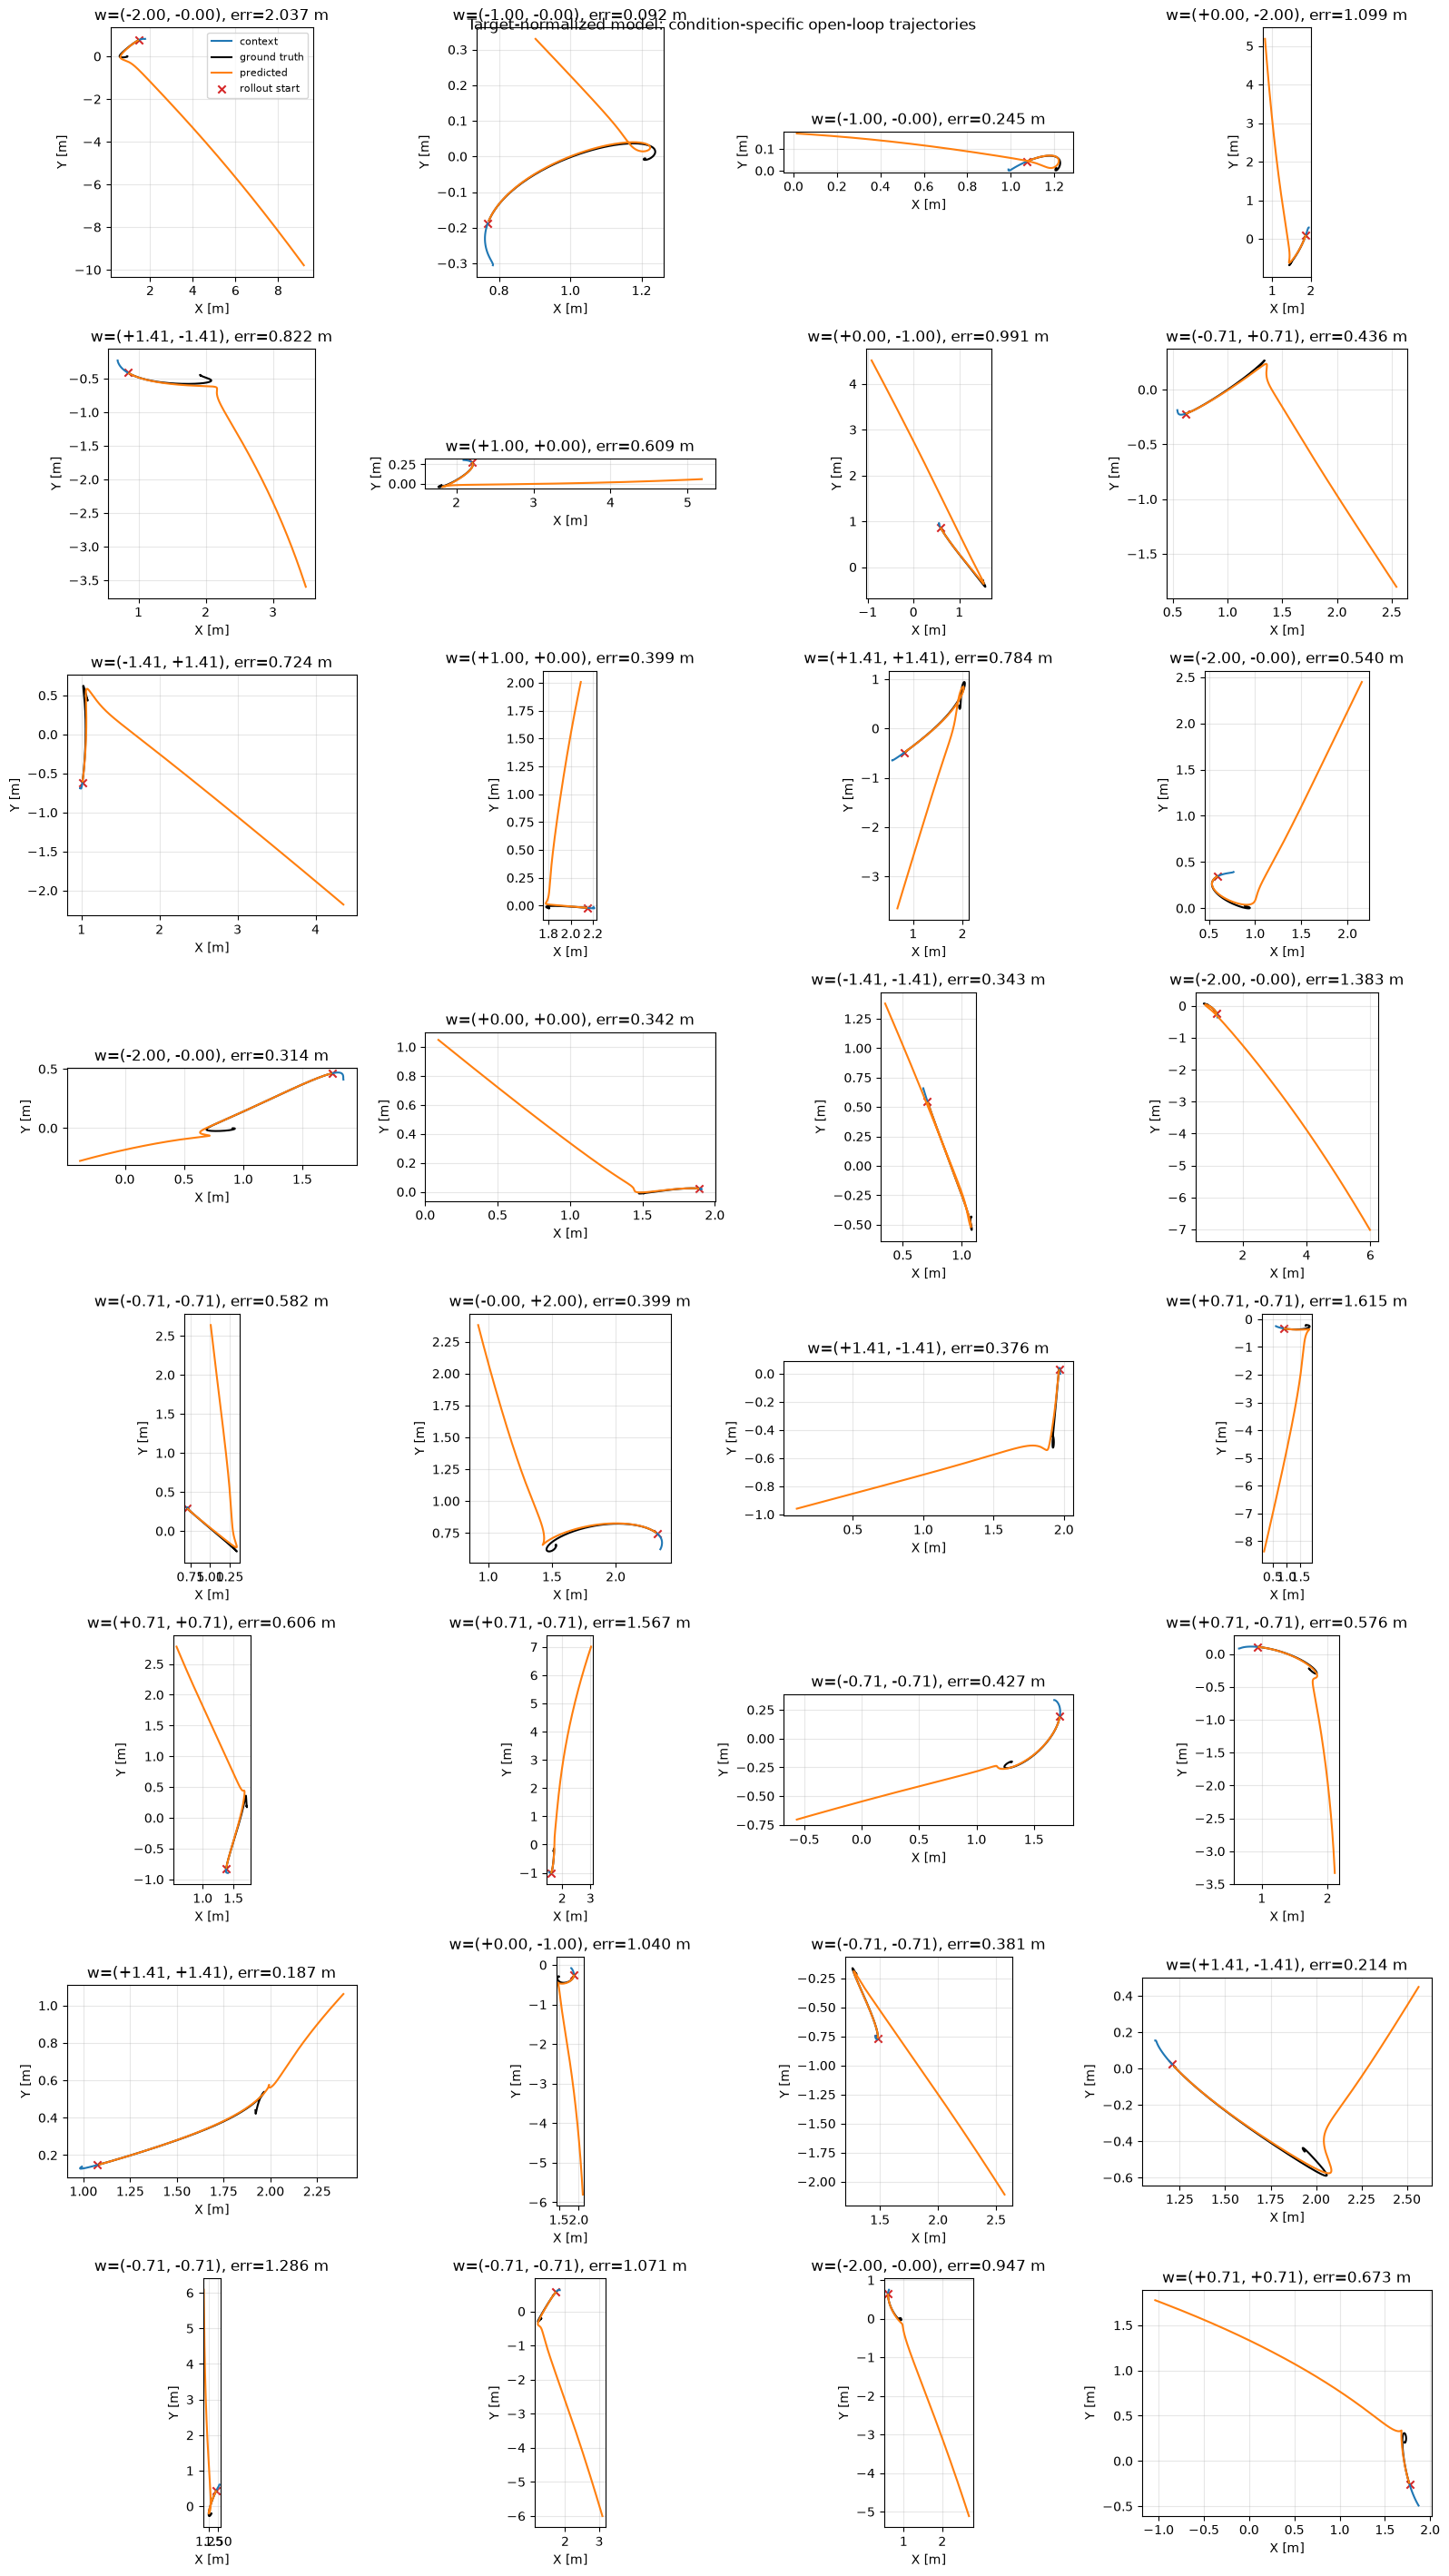

In [35]:
# The paper-style protocol is unchanged: infer one latent from the measured
# context, hold it fixed, and replay the same actions recursively for 5 s.
def target_normalized_learned_open_loop(
    initial_state, initial_context, action_sequence, step_keys
):
    fixed_latent = trajectory_encoder.apply(
        target_normalized_train_state.params["encoder"], initial_context
    )

    def learned_step(predicted_state, step_inputs):
        action, step_key = step_inputs
        current_state = state_vectors(
            predicted_state.quadrotor_state.p,
            predicted_state.quadrotor_state.R,
            predicted_state.quadrotor_state.v,
        )
        normalized_state_action = (
            jnp.concatenate([current_state, action], axis=-1) - input_mean
        ) / input_std
        prior_transition = prior_env._step(
            predicted_state, action, {}, step_key
        )
        prior_quad_state = prior_transition.state.quadrotor_state
        predicted_residual_norm = residual_model.apply(
            target_normalized_train_state.params["residual"],
            normalized_state_action,
            fixed_latent,
        )
        predicted_residual = (
            predicted_residual_norm * residual_target_std
            + residual_target_mean
        )
        corrected_quad_state = prior_quad_state.replace(
            p=prior_quad_state.p + predicted_residual[:3],
            v=prior_quad_state.v + predicted_residual[3:6],
        )
        corrected_state = prior_transition.state.replace(
            quadrotor_state=corrected_quad_state
        )
        return corrected_state, (corrected_quad_state, predicted_residual)

    _, outputs = jax.lax.scan(
        learned_step,
        initial_state,
        (action_sequence, step_keys),
    )
    predicted_states, predicted_residuals = outputs
    return predicted_states, predicted_residuals, fixed_latent

evaluate_target_normalized_open_loop = jax.jit(
    jax.vmap(target_normalized_learned_open_loop)
)
(
    target_normalized_open_loop_states,
    target_normalized_open_loop_residuals,
    target_normalized_open_loop_latents,
) = evaluate_target_normalized_open_loop(
    open_loop_initial_states,
    open_loop_initial_contexts,
    open_loop_actions,
    open_loop_keys,
)
target_normalized_open_loop_states.p.block_until_ready()

# Paper-style dynamics error: Euclidean position error at each open-loop
# timestep. Average over time within each rollout, then over rollouts so
# every trajectory receives equal weight regardless of valid duration.
open_loop_position_error = jnp.linalg.norm(
    target_normalized_open_loop_states.p - open_loop_true_states.p,
    axis=-1,
)
masked_open_loop_position_error = jnp.where(
    open_loop_valid_mask, open_loop_position_error, jnp.nan
)
per_rollout_cumulative_dynamics_error = (
    jnp.nansum(masked_open_loop_position_error, axis=1)
    / jnp.maximum(open_loop_valid_mask.sum(axis=1), 1)
)
cumulative_dynamics_error = jnp.mean(
    per_rollout_cumulative_dynamics_error
)
cumulative_dynamics_error_std = jnp.std(
    per_rollout_cumulative_dynamics_error
)
per_rollout_position_rmse = jnp.sqrt(
    jnp.nansum(jnp.square(masked_open_loop_position_error), axis=1)
    / jnp.maximum(open_loop_valid_mask.sum(axis=1), 1)
)
mean_per_rollout_position_rmse = jnp.mean(per_rollout_position_rmse)
std_per_rollout_position_rmse = jnp.std(per_rollout_position_rmse)
open_loop_winds = one_step_env_states.hidden_acceleration[
    open_loop_rollout_indices, 0, :
]
print(
    f"Open-loop position RMSE across rollouts: "
    f"{mean_per_rollout_position_rmse:.6e} +/- "
    f"{std_per_rollout_position_rmse:.6e} m"
)
open_loop_latent_mean = jnp.mean(
    target_normalized_open_loop_latents, axis=0
)
open_loop_latent_std = jnp.std(
    target_normalized_open_loop_latents, axis=0
)
print(
    f"Encoder latent aggregate mean/std: "
    f"{jnp.mean(target_normalized_open_loop_latents):.6e} / "
    f"{jnp.std(target_normalized_open_loop_latents):.6e}"
)
print("Encoder latent mean and standard deviation per dimension:")
for latent_index, (latent_mean, latent_std) in enumerate(zip(
    open_loop_latent_mean, open_loop_latent_std
)):
    print(
        f"  z[{latent_index:02d}]: mean={latent_mean:+.6e}, "
        f"std={latent_std:.6e}"
    )
print("Paper-style open-loop cumulative dynamics error:")
print(
    f"  mean Euclidean position error: "
    f"{cumulative_dynamics_error:.6e} +/- "
    f"{cumulative_dynamics_error_std:.6e} m"
)
for rollout_index, (wind, rollout_error) in enumerate(zip(
    open_loop_winds, per_rollout_cumulative_dynamics_error
)):
    print(
        f"  rollout {rollout_index}: "
        f"w=({float(wind[0]):+.2f}, {float(wind[1]):+.2f}) m/s^2, "
        f"error={float(rollout_error):.6e} m"
    )

# Match the paper's condition-specific XY visualization instead of
# averaging residual magnitudes across unrelated trajectories.
num_open_loop_plots = open_loop_rollout_indices.shape[0]
num_plot_columns = min(4, num_open_loop_plots)
num_plot_rows = (num_open_loop_plots + num_plot_columns - 1) // num_plot_columns
fig, axes = plt.subplots(
    num_plot_rows, num_plot_columns,
    figsize=(4.0 * num_plot_columns, 3.6 * num_plot_rows),
    squeeze=False,
)
flat_axes = axes.ravel()
for plot_index in range(num_open_loop_plots):
    ax = flat_axes[plot_index]
    rollout_id = open_loop_rollout_indices[plot_index]
    context_positions = one_step_quad_states.p[
        rollout_id, :context_length + 1
    ]
    true_positions = open_loop_true_states.p[plot_index]
    predicted_positions = target_normalized_open_loop_states.p[plot_index]
    valid_steps = open_loop_valid_mask[plot_index]
    wind = open_loop_winds[plot_index]
    ax.plot(
        context_positions[:, 0], context_positions[:, 1],
        label="context", color="C0",
    )
    ax.plot(
        jnp.where(valid_steps, true_positions[:, 0], jnp.nan),
        jnp.where(valid_steps, true_positions[:, 1], jnp.nan),
        label="ground truth", color="black",
    )
    ax.plot(
        jnp.where(valid_steps, predicted_positions[:, 0], jnp.nan),
        jnp.where(valid_steps, predicted_positions[:, 1], jnp.nan),
        label="predicted", color="C1",
    )
    ax.scatter(
        context_positions[-1, 0], context_positions[-1, 1],
        marker="x", color="C3", label="rollout start",
    )
    ax.set_title(
        f"w=({float(wind[0]):+.2f}, {float(wind[1]):+.2f}), "
        f"err={float(per_rollout_cumulative_dynamics_error[plot_index]):.3f} m"
    )
    ax.set_xlabel("X [m]")
    ax.set_ylabel("Y [m]")
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, alpha=0.3)
for unused_axis in flat_axes[num_open_loop_plots:]:
    unused_axis.set_visible(False)
flat_axes[0].legend(fontsize=8)
fig.suptitle(
    "Target-normalized model: condition-specific open-loop trajectories"
)
fig.tight_layout()
plt.show()

# Visualize the encoder outputs actually used by every multi-step validation
# rollouts. This evaluator holds the initial-context latent fixed, so its
# norm is constant and the step-to-step latent change is identically zero.
num_multi_step_latent_plots = target_normalized_open_loop_latents.shape[0]
multi_step_validation_latents = jnp.broadcast_to(
    target_normalized_open_loop_latents[
        :num_multi_step_latent_plots, None, :
    ],
    (
        num_multi_step_latent_plots,
        open_loop_horizon,
        target_normalized_open_loop_latents.shape[-1],
    ),
)

# fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
# for plot_index in range(num_multi_step_latent_plots):
#     rollout_id = int(open_loop_rollout_indices[plot_index])
#     rollout_latents = multi_step_validation_latents[plot_index]
#     axes[0].plot(
#         open_loop_time,
#         jnp.linalg.norm(rollout_latents, axis=-1),
#         label=f"rollout {rollout_id}",
#     )
#     axes[1].plot(
#         open_loop_time[1:],
#         jnp.linalg.norm(
#             rollout_latents[1:] - rollout_latents[:-1], axis=-1
#         ),
#     )
# axes[0].set_ylabel(r"$\|z_t\|_2$")
# axes[0].set_title(
#     "Target-normalized training: encoded multi-step validation conditions"
# )
# axes[0].legend()
# axes[1].set_xlabel("Open-loop time [s]")
# axes[1].set_ylabel(r"$\|z_t-z_{t-1}\|_2$")
# for ax in axes:
#     ax.grid(True, alpha=0.3)
# fig.tight_layout()
# plt.show()


Open-loop state distributions: encoder z versus sampled z ~ N(0, I)
  component      encoder mean/std         sampled mean/std
        p_x   +1.488111e+00/7.304822e-01   +4.330459e+00/2.605088e+01
        p_y   -1.216299e-01/1.304031e+00   -2.339356e+00/1.814688e+01
        p_z   +1.524865e+00/7.190821e-02   +1.524865e+00/7.190821e-02
        v_x   +1.083141e-01/8.046317e-01   +3.126304e+00/2.395731e+01
        v_y   -1.296368e-01/1.378199e+00   -3.381337e+00/1.844455e+01
        v_z   +7.027864e-03/1.879146e-01   +7.027920e-03/1.879146e-01

Learned residual distributions: encoder z versus sampled z ~ N(0, I)
  component      encoder mean/std         sampled mean/std
  delta_p_x   -3.124082e-05/2.343980e-04   +5.833691e-04/4.153498e-03
  delta_p_y   -6.696524e-05/2.822859e-04   -6.294957e-04/2.837024e-03
  delta_p_z   +2.247056e-11/5.597939e-10   -4.427025e-10/8.656553e-09
  delta_v_x   -2.150197e-03/2.372888e-02   +5.780600e-02/3.971970e-01
  delta_v_y   -7.908792e-03/3.120603e-02   -

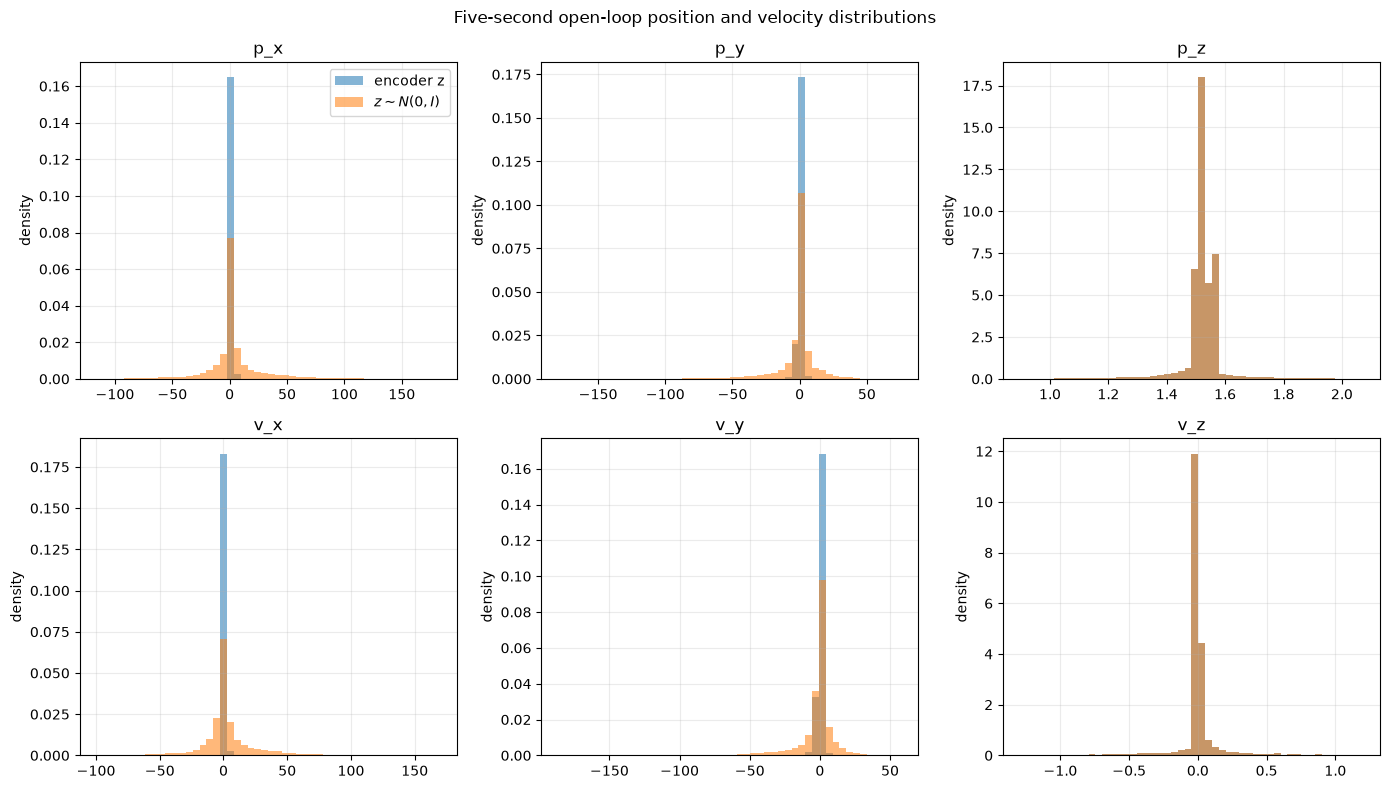

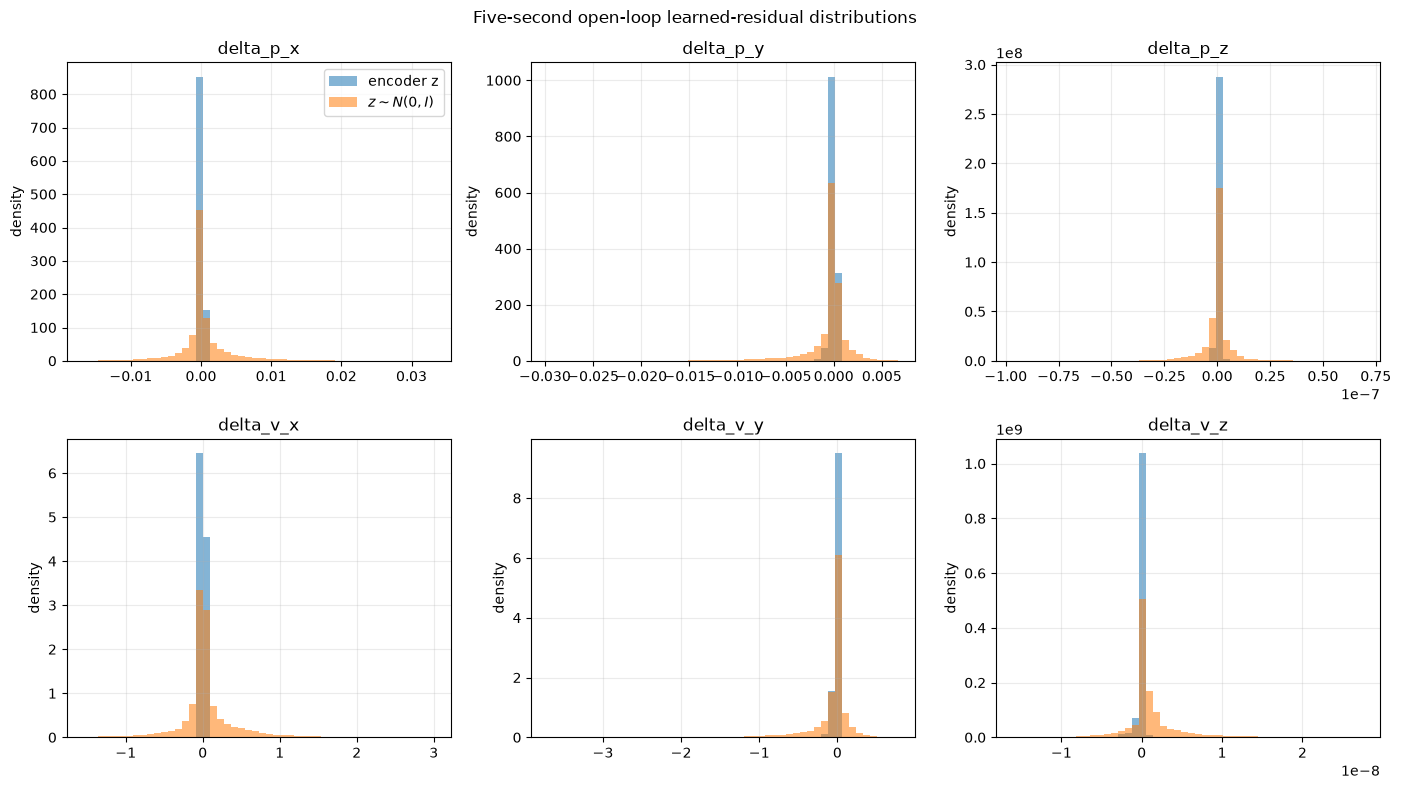

In [36]:
# Compare Section 13 against matched recursive rollouts driven by frozen
# z ~ N(0, I). Initial states, actions, keys, horizon, and masks are shared.
sampled_prior_open_loop_latents = jax.random.normal(
    experiment_key(60), target_normalized_open_loop_latents.shape
)

def sampled_prior_latent_open_loop(
    initial_state, fixed_latent, action_sequence, step_keys
):
    def sampled_latent_step(predicted_state, step_inputs):
        action, step_key = step_inputs
        current_state = state_vectors(
            predicted_state.quadrotor_state.p,
            predicted_state.quadrotor_state.R,
            predicted_state.quadrotor_state.v,
        )
        normalized_state_action = (
            jnp.concatenate([current_state, action], axis=-1) - input_mean
        ) / input_std
        prior_transition = prior_env._step(
            predicted_state, action, {}, step_key
        )
        prior_quad_state = prior_transition.state.quadrotor_state
        predicted_residual_norm = residual_model.apply(
            target_normalized_train_state.params["residual"],
            normalized_state_action,
            fixed_latent,
        )
        predicted_residual = (
            predicted_residual_norm * residual_target_std
            + residual_target_mean
        )
        corrected_quad_state = prior_quad_state.replace(
            p=prior_quad_state.p + predicted_residual[:3],
            v=prior_quad_state.v + predicted_residual[3:6],
        )
        corrected_state = prior_transition.state.replace(
            quadrotor_state=corrected_quad_state
        )
        return corrected_state, (corrected_quad_state, predicted_residual)

    _, outputs = jax.lax.scan(
        sampled_latent_step,
        initial_state,
        (action_sequence, step_keys),
    )
    return outputs

evaluate_sampled_prior_latent_open_loop = jax.jit(
    jax.vmap(sampled_prior_latent_open_loop)
)
(
    sampled_prior_open_loop_states,
    sampled_prior_open_loop_residuals,
) = evaluate_sampled_prior_latent_open_loop(
    open_loop_initial_states,
    sampled_prior_open_loop_latents,
    open_loop_actions,
    open_loop_keys,
)
sampled_prior_open_loop_states.p.block_until_ready()

encoder_open_loop_state_samples = jnp.concatenate([
    target_normalized_open_loop_states.p,
    target_normalized_open_loop_states.v,
], axis=-1)[open_loop_valid_mask]
sampled_prior_open_loop_state_samples = jnp.concatenate([
    sampled_prior_open_loop_states.p,
    sampled_prior_open_loop_states.v,
], axis=-1)[open_loop_valid_mask]
encoder_open_loop_residual_samples = (
    target_normalized_open_loop_residuals[open_loop_valid_mask]
)
sampled_prior_open_loop_residual_samples = (
    sampled_prior_open_loop_residuals[open_loop_valid_mask]
)

encoder_open_loop_state_samples_np = np.asarray(jax.device_get(
    encoder_open_loop_state_samples
))
sampled_prior_open_loop_state_samples_np = np.asarray(jax.device_get(
    sampled_prior_open_loop_state_samples
))
encoder_open_loop_residual_samples_np = np.asarray(jax.device_get(
    encoder_open_loop_residual_samples
))
sampled_prior_open_loop_residual_samples_np = np.asarray(jax.device_get(
    sampled_prior_open_loop_residual_samples
))

state_distribution_names = ["p_x", "p_y", "p_z", "v_x", "v_y", "v_z"]
residual_distribution_names = component_names

print("Open-loop state distributions: encoder z versus sampled z ~ N(0, I)")
print("  component      encoder mean/std         sampled mean/std")
for component_index, component_name in enumerate(state_distribution_names):
    encoder_values = encoder_open_loop_state_samples_np[:, component_index]
    sampled_values = sampled_prior_open_loop_state_samples_np[:, component_index]
    print(
        f"  {component_name:>9s}   "
        f"{encoder_values.mean():+.6e}/{encoder_values.std():.6e}   "
        f"{sampled_values.mean():+.6e}/{sampled_values.std():.6e}"
    )

print("\nLearned residual distributions: encoder z versus sampled z ~ N(0, I)")
print("  component      encoder mean/std         sampled mean/std")
for component_index, component_name in enumerate(residual_distribution_names):
    encoder_values = encoder_open_loop_residual_samples_np[:, component_index]
    sampled_values = sampled_prior_open_loop_residual_samples_np[:, component_index]
    print(
        f"  {component_name:>9s}   "
        f"{encoder_values.mean():+.6e}/{encoder_values.std():.6e}   "
        f"{sampled_values.mean():+.6e}/{sampled_values.std():.6e}"
    )

def shared_histogram_bins(first_values, second_values, num_bins=50):
    finite_values = np.concatenate([
        first_values[np.isfinite(first_values)],
        second_values[np.isfinite(second_values)],
    ])
    lower = finite_values.min()
    upper = finite_values.max()
    if np.isclose(lower, upper):
        padding = max(abs(lower) * 1e-3, 1e-8)
        lower -= padding
        upper += padding
    return np.linspace(lower, upper, num_bins + 1)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for component_index, (ax, component_name) in enumerate(zip(
    axes.ravel(), state_distribution_names
)):
    encoder_values = encoder_open_loop_state_samples_np[:, component_index]
    sampled_values = sampled_prior_open_loop_state_samples_np[:, component_index]
    bins = shared_histogram_bins(encoder_values, sampled_values)
    ax.hist(encoder_values, bins=bins, density=True, alpha=0.55, label="encoder z")
    ax.hist(sampled_values, bins=bins, density=True, alpha=0.55, label=r"$z \sim N(0,I)$")
    ax.set_title(component_name)
    ax.set_ylabel("density")
    ax.grid(True, alpha=0.25)
axes[0, 0].legend()
fig.suptitle("Five-second open-loop position and velocity distributions")
fig.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for component_index, (ax, component_name) in enumerate(zip(
    axes.ravel(), residual_distribution_names
)):
    encoder_values = encoder_open_loop_residual_samples_np[:, component_index]
    sampled_values = sampled_prior_open_loop_residual_samples_np[:, component_index]
    bins = shared_histogram_bins(encoder_values, sampled_values)
    ax.hist(encoder_values, bins=bins, density=True, alpha=0.55, label="encoder z")
    ax.hist(sampled_values, bins=bins, density=True, alpha=0.55, label=r"$z \sim N(0,I)$")
    ax.set_title(component_name)
    ax.set_ylabel("density")
    ax.grid(True, alpha=0.25)
axes[0, 0].legend()
fig.suptitle("Five-second open-loop learned-residual distributions")
fig.tight_layout()
plt.show()


Section 13 residual-model error versus analytical wind correction:
   delta_p_x: RMSE=1.323175e-04
   delta_p_y: RMSE=2.318412e-04
   delta_p_z: RMSE=5.602447e-10
   delta_v_x: RMSE=1.428016e-02
   delta_v_y: RMSE=2.676950e-02
   delta_v_z: RMSE=4.366570e-10


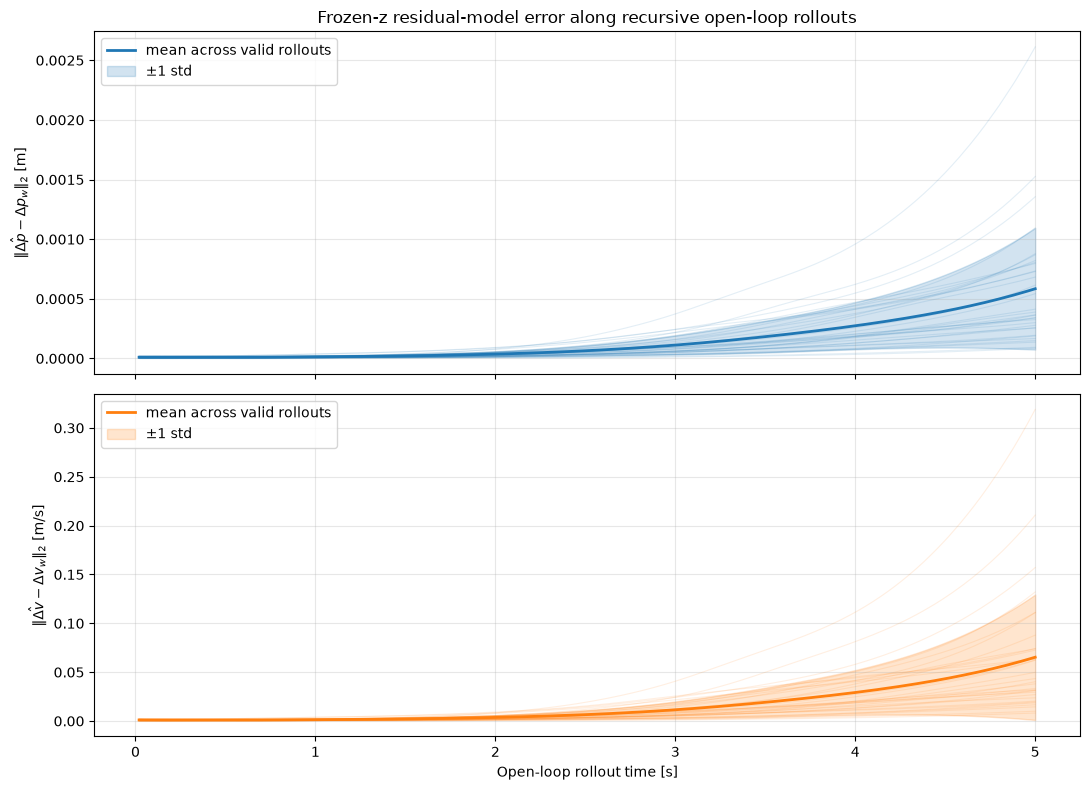

In [37]:
# Compare Section 13's learned correction at every recursive step against
# the exact constant-wind correction implemented by the environment.
# These stored predictions are D(s_hat_t, a_t, z_0): predicted state,
# recorded action, and the first-window latent frozen for the rollout.
analytical_delta_p = 0.5 * open_loop_winds * sim_dt**2
analytical_delta_v = open_loop_winds * sim_dt
analytical_wind_residual = jnp.concatenate(
    [analytical_delta_p, analytical_delta_v], axis=-1
)
analytical_wind_residual = jnp.broadcast_to(
    analytical_wind_residual[:, None, :],
    target_normalized_open_loop_residuals.shape,
)
open_loop_residual_model_error = (
    target_normalized_open_loop_residuals - analytical_wind_residual
)
open_loop_residual_model_error = jnp.where(
    open_loop_valid_mask[..., None],
    open_loop_residual_model_error,
    jnp.nan,
)
open_loop_position_residual_error_norm = jnp.linalg.norm(
    open_loop_residual_model_error[..., :3], axis=-1
)
open_loop_velocity_residual_error_norm = jnp.linalg.norm(
    open_loop_residual_model_error[..., 3:6], axis=-1
)
open_loop_residual_component_rmse = jnp.sqrt(jnp.nanmean(
    jnp.square(open_loop_residual_model_error), axis=(0, 1)
))
open_loop_residual_component_rmse.block_until_ready()

print("Section 13 residual-model error versus analytical wind correction:")
for component_name, component_rmse in zip(
    component_names, open_loop_residual_component_rmse
):
    print(f"  {component_name:>10s}: RMSE={component_rmse:.6e}")

position_error_mean = jnp.nanmean(
    open_loop_position_residual_error_norm, axis=0
)
position_error_std = jnp.nanstd(
    open_loop_position_residual_error_norm, axis=0
)
velocity_error_mean = jnp.nanmean(
    open_loop_velocity_residual_error_norm, axis=0
)
velocity_error_std = jnp.nanstd(
    open_loop_velocity_residual_error_norm, axis=0
)

fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)
for rollout_index in range(open_loop_rollout_indices.shape[0]):
    axes[0].plot(
        open_loop_time,
        open_loop_position_residual_error_norm[rollout_index],
        color="C0", alpha=0.12, linewidth=0.8,
    )
    axes[1].plot(
        open_loop_time,
        open_loop_velocity_residual_error_norm[rollout_index],
        color="C1", alpha=0.12, linewidth=0.8,
    )
axes[0].plot(
    open_loop_time, position_error_mean, color="C0", linewidth=2.0,
    label="mean across valid rollouts",
)
axes[0].fill_between(
    open_loop_time,
    jnp.maximum(position_error_mean - position_error_std, 0.0),
    position_error_mean + position_error_std,
    color="C0", alpha=0.2, label=r"$\pm 1$ std",
)
axes[1].plot(
    open_loop_time, velocity_error_mean, color="C1", linewidth=2.0,
    label="mean across valid rollouts",
)
axes[1].fill_between(
    open_loop_time,
    jnp.maximum(velocity_error_mean - velocity_error_std, 0.0),
    velocity_error_mean + velocity_error_std,
    color="C1", alpha=0.2, label=r"$\pm 1$ std",
)
axes[0].set_ylabel(r"$\|\hat{\Delta p}-\Delta p_w\|_2$ [m]")
axes[1].set_ylabel(r"$\|\hat{\Delta v}-\Delta v_w\|_2$ [m/s]")
axes[1].set_xlabel("Open-loop rollout time [s]")
axes[0].set_title(
    "Frozen-z residual-model error along recursive open-loop rollouts"
)
for ax in axes:
    ax.grid(True, alpha=0.3)
    ax.legend()
fig.tight_layout()
plt.show()


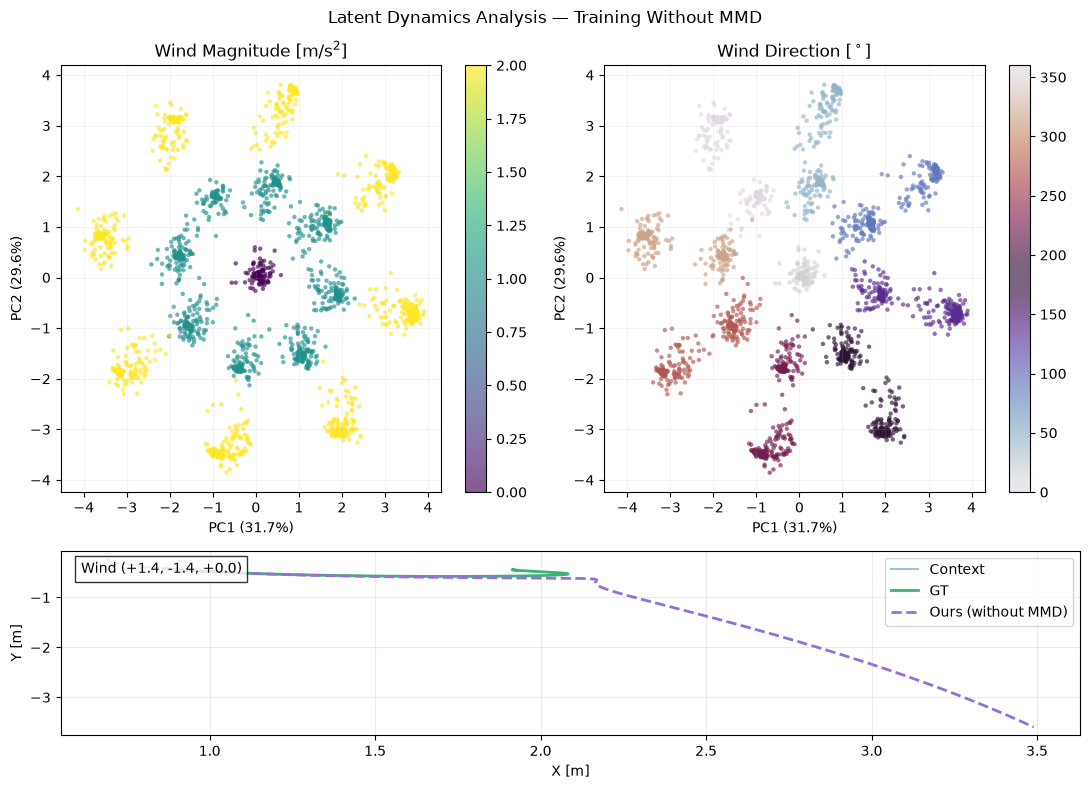

Without-MMD PCA variance explained by PC1 + PC2: 61.31%
Latent windows plotted: 2,400
Representative rollout: 4, wind=[ 1.414214  -1.4142131  0.       ]


In [38]:
# Paper-style latent analysis for the target-normalized model trained without MMD.
# Wind labels are used only to color the final encoder outputs.
no_mmd_plot_latents = np.asarray(jax.device_get(
    target_normalized_validation_latents
))
no_mmd_plot_winds = np.asarray(jax.device_get(
    env_states.hidden_acceleration[validation_rollout_ids, 0, :]
))
assert no_mmd_plot_latents.shape == (
    no_mmd_plot_winds.shape[0], latent_dim
)

# Compute one centered PCA projection and reuse the same 2-D coordinates in
# the magnitude and direction panels.
no_mmd_latent_mean = no_mmd_plot_latents.mean(axis=0, keepdims=True)
no_mmd_centered_latents = no_mmd_plot_latents - no_mmd_latent_mean
_, no_mmd_singular_values, no_mmd_pca_directions = np.linalg.svd(
    no_mmd_centered_latents, full_matrices=False
)
no_mmd_latent_2d = no_mmd_centered_latents @ no_mmd_pca_directions[:2].T
no_mmd_pca_variance = no_mmd_singular_values**2
no_mmd_explained_variance = (
    no_mmd_pca_variance / max(no_mmd_pca_variance.sum(), 1e-12)
)
no_mmd_wind_magnitude = np.linalg.norm(no_mmd_plot_winds, axis=-1)
no_mmd_nonzero_wind = no_mmd_wind_magnitude > 1e-8
no_mmd_wind_direction = (
    np.degrees(np.arctan2(
        no_mmd_plot_winds[:, 1], no_mmd_plot_winds[:, 0]
    )) % 360.0
)

# Use the existing non-MMD open-loop prediction for the representative trace.
no_mmd_desired_wind = np.asarray([2.0, -2.0, 0.0])
no_mmd_available_winds = np.asarray(jax.device_get(open_loop_winds))
no_mmd_representative_index = int(np.argmin(np.linalg.norm(
    no_mmd_available_winds - no_mmd_desired_wind[None, :], axis=-1
)))
no_mmd_rollout_id = int(
    open_loop_rollout_indices[no_mmd_representative_index]
)
no_mmd_representative_valid = np.asarray(jax.device_get(
    open_loop_valid_mask[no_mmd_representative_index]
))
no_mmd_context_xy = np.asarray(jax.device_get(
    one_step_quad_states.p[no_mmd_rollout_id, :context_length + 1, :2]
))
no_mmd_true_xy = np.asarray(jax.device_get(
    open_loop_true_states.p[no_mmd_representative_index, :, :2]
))
no_mmd_predicted_xy = np.asarray(jax.device_get(
    target_normalized_open_loop_states.p[
        no_mmd_representative_index, :, :2
    ]
))
no_mmd_representative_wind = no_mmd_available_winds[
    no_mmd_representative_index
]

fig = plt.figure(figsize=(11, 8))
no_mmd_grid = fig.add_gridspec(2, 2, height_ratios=[3.0, 1.3])
no_mmd_magnitude_axis = fig.add_subplot(no_mmd_grid[0, 0])
no_mmd_direction_axis = fig.add_subplot(no_mmd_grid[0, 1])
no_mmd_trajectory_axis = fig.add_subplot(no_mmd_grid[1, :])

no_mmd_magnitude_points = no_mmd_magnitude_axis.scatter(
    no_mmd_latent_2d[:, 0], no_mmd_latent_2d[:, 1],
    c=no_mmd_wind_magnitude, cmap="viridis",
    s=10, alpha=0.65, linewidths=0.0,
)
no_mmd_magnitude_axis.set_title(r"Wind Magnitude [$\mathrm{m/s^2}$]")
fig.colorbar(no_mmd_magnitude_points, ax=no_mmd_magnitude_axis)

no_mmd_direction_axis.scatter(
    no_mmd_latent_2d[~no_mmd_nonzero_wind, 0],
    no_mmd_latent_2d[~no_mmd_nonzero_wind, 1],
    color="lightgrey", s=10, alpha=0.65, linewidths=0.0,
)
no_mmd_direction_points = no_mmd_direction_axis.scatter(
    no_mmd_latent_2d[no_mmd_nonzero_wind, 0],
    no_mmd_latent_2d[no_mmd_nonzero_wind, 1],
    c=no_mmd_wind_direction[no_mmd_nonzero_wind],
    cmap="twilight", vmin=0.0, vmax=360.0,
    s=10, alpha=0.65, linewidths=0.0,
)
no_mmd_direction_axis.set_title(r"Wind Direction [$^\circ$]")
fig.colorbar(no_mmd_direction_points, ax=no_mmd_direction_axis)

for no_mmd_axis in (no_mmd_magnitude_axis, no_mmd_direction_axis):
    no_mmd_axis.set_xlabel(
        f"PC1 ({100.0 * no_mmd_explained_variance[0]:.1f}%)"
    )
    no_mmd_axis.set_ylabel(
        f"PC2 ({100.0 * no_mmd_explained_variance[1]:.1f}%)"
    )
    no_mmd_axis.grid(True, alpha=0.15)

no_mmd_trajectory_axis.plot(
    no_mmd_context_xy[:, 0], no_mmd_context_xy[:, 1],
    color="tab:blue", alpha=0.45, linewidth=1.5, label="Context",
)
no_mmd_trajectory_axis.plot(
    no_mmd_true_xy[no_mmd_representative_valid, 0],
    no_mmd_true_xy[no_mmd_representative_valid, 1],
    color="mediumseagreen", linewidth=2.0, label="GT",
)
no_mmd_trajectory_axis.plot(
    no_mmd_predicted_xy[no_mmd_representative_valid, 0],
    no_mmd_predicted_xy[no_mmd_representative_valid, 1],
    color="mediumpurple", linestyle="--", linewidth=2.0,
    label="Ours (without MMD)",
)
no_mmd_trajectory_axis.text(
    0.02, 0.88,
    f"Wind ({no_mmd_representative_wind[0]:+.1f}, "
    f"{no_mmd_representative_wind[1]:+.1f}, "
    f"{no_mmd_representative_wind[2]:+.1f})",
    transform=no_mmd_trajectory_axis.transAxes,
    bbox={"facecolor": "white", "alpha": 0.8},
)
no_mmd_trajectory_axis.set_xlabel("X [m]")
no_mmd_trajectory_axis.set_ylabel("Y [m]")
no_mmd_trajectory_axis.grid(True, alpha=0.25)
no_mmd_trajectory_axis.legend()
fig.suptitle("Latent Dynamics Analysis — Training Without MMD")
fig.tight_layout()
plt.show()

print(
    "Without-MMD PCA variance explained by PC1 + PC2: "
    f"{100.0 * no_mmd_explained_variance[:2].sum():.2f}%"
)
print(f"Latent windows plotted: {no_mmd_plot_latents.shape[0]:,}")
print(
    f"Representative rollout: {no_mmd_rollout_id}, "
    f"wind={no_mmd_representative_wind}"
)
